In [ ]:
# install torcheval
!pip install torcheval
!pip install torchmetrics

## Dataset Import

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import torcheval.metrics.functional as metrics
from torchmetrics.classification import MulticlassAveragePrecision
import json
from sklearn.model_selection import train_test_split
import torch.optim.lr_scheduler as lr_scheduler
from torchsummary import summary

"""torch.manual_seed(42)
torch.cuda.manual_seed(42)
torch.cuda.manual_seed_all(42)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)"""

import random

# Step 1: Set all random seeds
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

set_seed(42)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(42)

In [ ]:
# Drive setup
# Connect to drive so we can really store out outputs
from google.colab import drive
drive.mount('/content/drive')
output_path = "/content/drive/MyDrive/cv_p3_outputs"
#output_path = "/content/drive/MyDrive/UU Courses/ComputerVision/cv_p3_outputs"

In [ ]:
# Use GPU if the its available
device = torch.device('cuda' if torch.cuda.is_available() else "cpu")

# Right now:
# Train data: 4k
# Test data: k
# Valid data: k
# Some hyper parameters
batch_size = 32
num_epochs = 200 # We've implemented early stopping anyway
learning_rate = 0.001
num_classes = 10
early_stop_tolerance = 5
model_performance = {}

# Transform with normalization
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

# load data
og_train_dataset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Stratification for a nice split of training-validation data so that all classes are represented during trainin
training_labels = [og_train_dataset[i][1] for i in range(len(og_train_dataset))]
train_indices, val_indices = train_test_split(
    range(len(og_train_dataset)),
    test_size=0.2,  # 20% validation data
    stratify=training_labels,  # Preserve class distribution
    random_state=42
)

train_dataset = torch.utils.data.Subset(og_train_dataset, train_indices)
val_dataset = torch.utils.data.Subset(og_train_dataset, val_indices)


# Divide traininf data as training-validation
# We use generator for reproducability
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=g)
valid_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=True, generator=g)

### Data Import Augmented

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

# Define original (no augmentation) transformation
base_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

# Define augmentation transformations (for training only)
augment_transforms = [
    transforms.Compose([
        transforms.RandomHorizontalFlip(p=1.0),  # Flip all images
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
    ]),
    transforms.Compose([
        transforms.RandomRotation(degrees=30),  # Rotate all images
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
    ]),
    transforms.Compose([
        transforms.RandomVerticalFlip(p=1) ,  # Flip all images
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
    ])
]

# Load original dataset (no augmentation)
full_dataset = torchvision.datasets.CIFAR10(root="./data_au", train=True, download=True, transform=base_transform)

# Split into training (80%) and validation (20%)
train_size = int(0.8 * len(full_dataset))
valid_size = len(full_dataset) - train_size
train_data, valid_data = torch.utils.data.random_split(full_dataset, [train_size, valid_size])

# Load augmented datasets (for training only)
augmented_datasets = [
    torchvision.datasets.CIFAR10(root="./data_au", train=True, download=True, transform=aug_transform)
    for aug_transform in augment_transforms
]

# Split augmented datasets using the same indices as train_data
train_augmented_sets = [torch.utils.data.Subset(aug_dataset, train_data.indices) for aug_dataset in augmented_datasets]

# Combine original training data with augmented data
combined_train_data = torch.utils.data.ConcatDataset([train_data] + train_augmented_sets)

# Data Loaders
batch_size = 32
train_loader = torch.utils.data.DataLoader(combined_train_data, batch_size=batch_size, shuffle=True)
valid_loader = torch.utils.data.DataLoader(valid_data, batch_size=batch_size, shuffle=False)

# Load test set (no augmentation)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])
test_dataset = torchvision.datasets.CIFAR10(root="./data_au", train=False, download=True, transform=test_transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Original train set size: {train_size}")
print(f"Final training set size (with augmentation): {len(combined_train_data)}")
print(f"Validation set size: {valid_size}")


## Model Setup

### CIFAR10_lenet

In [ ]:
# Class def for out lenet
class Lenet(nn.Module):
    def __init__(self, num_classes=10):
        super(Lenet, self).__init__()
        self.relu = nn.ReLU()

        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 6, kernel_size=5) # 6x28x28
        self.pool1 = nn.AvgPool2d(2, 2) # 6x14x14
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5) # 16x10x10
        self.pool2 = nn.AvgPool2d(2, 2) # 16x5x5
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5) # 120x1x1

        # Fully connected layers
        self.fc1 = nn.Linear(120, 84)
        self.fc2 = nn.Linear(84, num_classes)

        # Weight initialization
        self.apply(self.init_weights)

        self.name = "lenet_original"

    def init_weights(self, module):
        if isinstance(module, nn.Linear) or isinstance(module, nn.Conv2d):
            nn.init.kaiming_uniform_(module.weight, mode='fan_in', nonlinearity='relu')

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool1(x)
        x = self.relu(self.conv2(x))
        x = self.pool2(x)
        x = self.relu(self.conv3(x))
        x = torch.flatten(x, 1)  # Flatten before FC layers
        x = self.relu(self.fc1(x))
        x = self.fc2(x)  # No ReLU here
        return x

    def who(self):
      return self.name



### CIFAR10_model1 (BatchNorm)

In [ ]:
# Class def for out lenet
class Lenet_bn(nn.Module):
  def __init__(self):
    super(Lenet_bn, self).__init__()
    # initially the images are 3x32x32
    self.relu = nn.ReLU()
    self.conv1 = nn.Conv2d(3, 6, 5) # After convolution1 with 6 kernels we get 6x28x28
    self.bn1 = nn.BatchNorm2d(6)     # BatchNorm after Conv1
    self.pool1 = nn.MaxPool2d(2, 2) # we use max pooling, we get 6x14x14
    self.conv2 = nn.Conv2d(6, 16, 5) # After convolution2 with 16 kernels we get 16x10x10
    self.bn2 = nn.BatchNorm2d(16)     # BatchNorm after Conv2
    self.pool2 = nn.MaxPool2d(2, 2) # after max_pooling 2, we get 16x5x5
    self.conv3 = nn.Conv2d(16, 120, kernel_size=5) # 120x1x1

    self.bn3 = nn.BatchNorm1d(84)    # BatchNorm after FC1
    self.fc1 = nn.Linear(120, 84)
    self.fc2 = nn.Linear(84, 10)
    # We dont add the softmax here because torch.CrossEntropyLoss takes logits as inputs
    self.apply(self.init_weights) # apply weight init
    self.name = "lenet_bn"

  # init weights with kaiming_uniform
  def init_weights(self, module):
      if isinstance(module, nn.Linear) or isinstance(module, nn.Conv2d):
        nn.init.kaiming_uniform_(module.weight, mode='fan_in', nonlinearity='relu')


  # Forward pass function
  def forward(self, x):
    out = self.relu(self.conv1(x)) # 1st convolution layer + ReLU activation
    out = self.bn1(out)               # BatchNorm after Conv1
    out = self.pool1(out) # 1st pooling layer
    out = self.relu(self.conv2(out)) # 2nd convolution later + ReLU
    out = self.bn2(out)               # BatchNorm after Conv2
    out = self.pool2(out)
    out = self.relu(self.conv3(out))
    out = torch.flatten(out, 1)  # Flatten before FC layers
    out = self.relu(self.fc1(out)) # 1st fully connected layer + ReLU
    out = self.bn3(out)               # BatchNorm after f1
    out = self.relu(self.fc2(out)) # 2nd fully connected layer + ReLU

    return out

  def who(self):
    return self.name
print("done")

### CIFAR10_model2 (BatchNorm + dropout)

In [ ]:
# Class def for variant2, batch normalization and dropout
class Lenet_dropout(nn.Module):
  def __init__(self):
    super(Lenet_dropout, self).__init__()
    # initially the images are 3x32x32
    self.relu = nn.ReLU()
    self.conv1 = nn.Conv2d(3, 6, 5) # After convolution1 with 6 kernels we get 6x28x28
    self.bn1 = nn.BatchNorm2d(6) # BatchNorm after Conv1
    self.pool1 = nn.MaxPool2d(2, 2) # we use max pooling, we get 6x14x14
    self.conv2 = nn.Conv2d(6, 16, 5) # After convolution2 with 16 kernels we get 16x10x10
    self.bn2 = nn.BatchNorm2d(16) # BatchNorm after Conv2
    self.pool2 = nn.MaxPool2d(2, 2) # after max_pooling 2, we get 16x5x5
    self.conv3 = nn.Conv2d(16, 120, kernel_size=5) # 120x1x1

    self.dropout1 = nn.Dropout(0.2)
    self.bn3 = nn.BatchNorm1d(84) # BatchNorm after FC1
    self.fc1 = nn.Linear(120, 84)
    self.dropout2 = nn.Dropout(0.2)
    self.fc2 = nn.Linear(84, 10)
    self.name = "lenet_dropout_bn"

  # init weights with kaiming_uniform
  def init_weights(self, module):
      if isinstance(module, nn.Linear) or isinstance(module, nn.Conv2d):
        nn.init.kaiming_uniform_(module.weight, mode='fan_in', nonlinearity='relu')


  #  Forward pass function
  def forward(self, x, return_features=False):
    out = self.relu(self.conv1(x)) # 1st convolution layer + ReLU activation
    out = self.bn1(out)               # BatchNorm after Conv1
    out = self.pool1(out) # 1st pooling layer
    out = self.relu(self.conv2(out)) # 2nd convolution later + ReLU
    out = self.dropout1(out) # dropout
    out = self.bn2(out)               # BatchNorm after Conv2
    out = self.pool2(out) # 2nd pooling layer + flattening the output to feed into fully connected layers

    out = self.relu(self.conv3(out))
    out = torch.flatten(out, 1)  # Flatten before FC layers
    fc1_x = self.relu(self.fc1(out)) # 1st fully connected layer + ReLU
    if return_features:
        return fc1_x
    out = self.dropout2(fc1_x) # dropout
    out = self.bn3(out)               # BatchNorm after f1
    out = self.relu(self.fc2(out)) # 2nd fully connected layer + ReLU

    return out

  def who(self):
    return self.name
print("done")

## Training and Validation Functions

In [ ]:
# Training
def train_model(model, train_loader, valid_loader, num_epochs=num_epochs, tolerance=early_stop_tolerance, early_stopping=True, num_classes=num_classes):
  loss_func = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate)
  training_loss_list = []
  validation_loss_list = []
  accuracy_list = []
  accuracy_list_t = []
  min_val_loss = float('inf') # for early stopping comparisons
  counter = 0 # Count of non-improved epochs
  for epoch in range(num_epochs):
    training_loss = 0.0
    val_loss = 0.0
    correct_t = 0
    tot_images_t = 0
    for step,(batch, labels) in enumerate(train_loader):
      # send data to device
      batch = batch.to(device)
      labels = labels.to(device)
      # Forward pass
      logits = model(batch)
      # Loss
      loss = loss_func(logits, labels)
      # Backward pass
      loss.backward()
      # Update the parameters
      optimizer.step()
      # zero_grad
      optimizer.zero_grad()
      # Accumulate training loss, no need to calculate gradients
      with torch.no_grad():
        training_loss += loss.item()
        # Find the most probable class indices
        _, predicted_labels = torch.max(logits, 1)
        # increase total img count by batch sample size
        tot_images_t += labels.size(0)
        # increase correct classification through bit-wise and
        correct_t += (predicted_labels == labels).sum().item()

    with torch.no_grad():
      _, _, correct, tot_images, val_loss, precision, recall, avg_precision = validation(model, valid_loader, save_model_performance=False, num_classes=num_classes)
      training_loss /= len(train_loader)
      training_loss_list.append(training_loss)
      validation_loss_list.append(val_loss)
      accuracy_list.append(correct / tot_images)
      accuracy_list_t.append(correct_t / tot_images_t)

      print(f"Epoch: {epoch+1}, training loss: {training_loss}, validation loss: {val_loss}, validation accuracy: {correct/tot_images}")

      # Make validation comparisons and update min loss and counter
      if val_loss < min_val_loss:
        min_val_loss = val_loss
        counter = 0
      else:
        counter +=1

      # Tolerance comparison, if validation error is not getting better break and finish training
      if early_stopping and counter >= tolerance:
        print(f"Training early stopped in epoch: {epoch+1}")
        break

  return model, training_loss_list, validation_loss_list, accuracy_list, accuracy_list_t


# Validation
def validation(model, dataloader, save_model_performance=False, run_count=0, num_classes=num_classes):
  model_performance = {}
  loss_func = nn.CrossEntropyLoss()
  model.eval()
  with torch.no_grad():
    # a list for all logits
    all_probs = []
    # a list for all labels
    all_labels = []
    # correct classification count
    correct = 0
    # total validation image count
    tot_images = 0
    # If we want class based analysis we can fill the following lists:
    correct_class_counts = [0 for i in range(num_classes)]
    correct_tot_class_counts = [0 for i in range(num_classes)]
    val_loss = 0.0
    # batch by batch
    for step, (valid_batch, valid_labels) in enumerate(dataloader):
      # send data to device
      valid_batch = valid_batch.to(device)
      valid_labels = valid_labels.to(device)
      # Forward pass
      pred_logit = model(valid_batch)
      all_probs.append(pred_logit)
      all_labels.append(valid_labels)

      # Find the most probable class indices
      _, predicted_labels = torch.max(pred_logit, 1)
      # increase total img count by batch sample size
      tot_images += valid_labels.size(0)
      # increase correct classification through bit-wise and
      correct += (predicted_labels == valid_labels).sum().item()
      # accumulate val_loss for early stopping
      val_loss += loss_func(pred_logit, valid_labels).item()

      all_probs_t = torch.cat(all_probs, dim=0)
      all_labels_t = torch.cat(all_labels, dim=0)

      # Now that we have the lists, we can iteratively calculate performance metrics
      # Accuracy
      accuracy = metrics.multiclass_accuracy(all_probs_t, all_labels_t, num_classes=num_classes)
      # F1 score
      f1_score = metrics.multiclass_f1_score(all_probs_t, all_labels_t, num_classes=num_classes)
      # Precision
      precision = metrics.multiclass_precision(all_probs_t, all_labels_t, num_classes=num_classes)
      # Recall
      recall = metrics.multiclass_recall(all_probs_t, all_labels_t, num_classes=num_classes)
      # PR Curve
      pr_curve = metrics.multiclass_precision_recall_curve(all_probs_t, all_labels_t, num_classes=num_classes)
      # Average precision
      avg_precision_metric = MulticlassAveragePrecision(num_classes=num_classes)
      avg_precision = avg_precision_metric(all_probs_t, all_labels_t)


      model_performance["model_name"] = model.who()
      model_performance["accuracy"] = accuracy.item()
      model_performance["precision"] = precision.item()
      model_performance["recall"] = recall.item()
      model_performance["f1_score"] = f1_score.item()
      #model_performance["pr_curve"] = pr_curve
      model_performance["avg_precision"] = avg_precision.item()

      # If we want to save model performance
      if save_model_performance:
        #print(model_performance)

        # Save model performance
        with open(f"{output_path}/{model_performance['model_name']}{str(run_count)}_.json", "w") as outfile:
          json.dump(model_performance, outfile)

    model.train()
    return all_probs, all_labels, correct, tot_images, val_loss/len(dataloader), precision.item(), recall.item(), avg_precision.item()


# Single trainings
These are the single run training-validation scripts. We have multiple training sessions later in the notebook to perform statistical analysis to select the best model.

## Originals

In [ ]:
import os
output_path = "./outputs"
os.makedirs(output_path, exist_ok=True)
os.makedirs(output_path + "/model_params", exist_ok=True)
os.makedirs(output_path + "/results", exist_ok=True)

In [ ]:
# Baseline Lenet, single training, validation, parameters, and results saving.
set_seed(42)
results = {}
tot_val_loss = 0
tot_training_loss = 0
results["name"] = "baseline_lenet"
max_avg_precision = 0
min_val_loss = float("inf")


model_v0 = Lenet().to(device)
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_v0.parameters(), lr=learning_rate)

# Train
model_v0, training_loss_list, validation_loss_list, accuracy_list, accuracy_list_t = train_model(model_v0, train_loader, valid_loader, num_epochs=num_epochs)
# Validate
all_probs, all_labels, correct, tot_images, val_loss, precision, recall, avg_precision = validation(model_v0, valid_loader, save_model_performance=False, run_count=0)
acc = 100 * correct / tot_images
print(f"Accuracy: {acc}%")
print(f"Training loss list: {training_loss_list}")
print(f"Validation loss list: {validation_loss_list}")
print(f"Last validation loss: {validation_loss_list[-1]}")

results[0] = {"accuracy": acc, "precision": precision, "recall": recall, "avg_precision": avg_precision, "validation_loss": val_loss, "training_loss": training_loss_list[-1]}
results[0]["training_loss_per_epoch"] = training_loss_list
results[0]["validation_loss_per_epoch"] = validation_loss_list
results[0]["validation_accuracy_per_epoch"] = accuracy_list
results[0]["training_accuracy_per_epoch"] = accuracy_list_t
torch.save(model_v0.state_dict(), f"{output_path}/model_params/lenet_baseline_parameters_single_run.pth")
with open(f"{output_path}/results/lenet_baseline_results_single_run.json", "w") as outfile:
  json.dump(results, outfile)

# get the summary
summary(model_v0, (3, 32, 32))

In [ ]:
# Lenet batch norm, single training, validation, parameters, and results saving.
set_seed(42)
results = {}
tot_val_loss = 0
tot_training_loss = 0
results["name"] = "lenet_bn"
max_avg_precision = 0
min_val_loss = float("inf")


model_v1 = Lenet_bn().to(device)
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_v1.parameters(), lr=learning_rate)

# Train
model_v1, training_loss_list, validation_loss_list, accuracy_list, accuracy_list_t = train_model(model_v1, train_loader, valid_loader, num_epochs=num_epochs)
# Validate
all_probs, all_labels, correct, tot_images, val_loss, precision, recall, avg_precision = validation(model_v1, valid_loader, save_model_performance=False, run_count=0)
acc = 100 * correct / tot_images
print(f"Accuracy: {acc}%")
print(f"Training loss list: {training_loss_list}")
print(f"Validation loss list: {validation_loss_list}")
print(f"Last validation loss: {validation_loss_list[-1]}")

results[0] = {"accuracy": acc, "precision": precision, "recall": recall, "avg_precision": avg_precision, "validation_loss": val_loss, "training_loss": training_loss_list[-1]}
results[0]["training_loss_per_epoch"] = training_loss_list
results[0]["validation_loss_per_epoch"] = validation_loss_list
results[0]["validation_accuracy_per_epoch"] = accuracy_list
results[0]["training_accuracy_per_epoch"] = accuracy_list_t
torch.save(model_v1.state_dict(), f"{output_path}/model_params/lenet_batchnorm_parameters_single_run.pth")
with open(f"{output_path}/results/lenet_batchnorm_results_single_run.json", "w") as outfile:
  json.dump(results, outfile)

# get the summary
summary(model_v1, (3, 32, 32))

In [ ]:
# Lenet batch norm + dropot, single training, validation, parameters, and results saving.
set_seed(42)
results = {}
tot_val_loss = 0
tot_training_loss = 0
results["name"] = "lenet_bn_dropout"
max_avg_precision = 0
min_val_loss = float("inf")

model_v2 = Lenet_dropout().to(device)
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_v2.parameters(), lr=learning_rate)

# Train
model_v2, training_loss_list, validation_loss_list, accuracy_list, accuracy_list_t = train_model(model_v2, train_loader, valid_loader, num_epochs=num_epochs)
# Validate
all_probs, all_labels, correct, tot_images, val_loss, precision, recall, avg_precision = validation(model_v2, valid_loader, save_model_performance=False, run_count=0)
acc = 100 * correct / tot_images
print(f"Accuracy: {acc}%")
print(f"Training loss list: {training_loss_list}")
print(f"Validation loss list: {validation_loss_list}")
print(f"Last validation loss: {validation_loss_list[-1]}")

results[0] = {"accuracy": acc, "precision": precision, "recall": recall, "avg_precision": avg_precision, "validation_loss": val_loss, "training_loss": training_loss_list[-1]}
results[0]["training_loss_per_epoch"] = training_loss_list
results[0]["validation_loss_per_epoch"] = validation_loss_list
results[0]["validation_accuracy_per_epoch"] = accuracy_list
results[0]["training_accuracy_per_epoch"] = accuracy_list_t
torch.save(model_v2.state_dict(), f"{output_path}/model_params/lenet_bn_dropout_parameters_single_run.pth")
with open(f"{output_path}/results/lenet_bn_dropout_results_single_run.json", "w") as outfile:
  json.dump(results, outfile)

# get the summary
summary(model_v2, (3, 32, 32))

# Model Comparisons in pairs

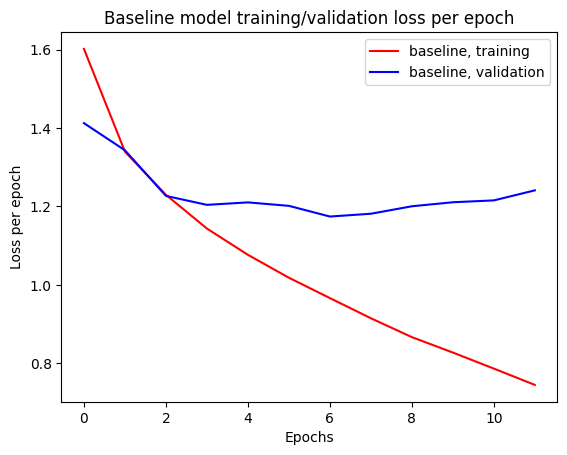

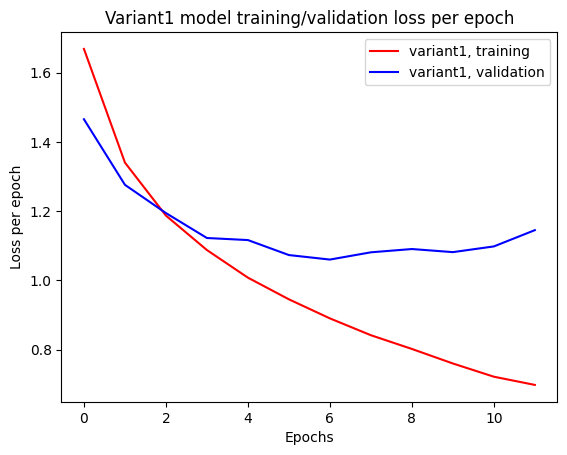

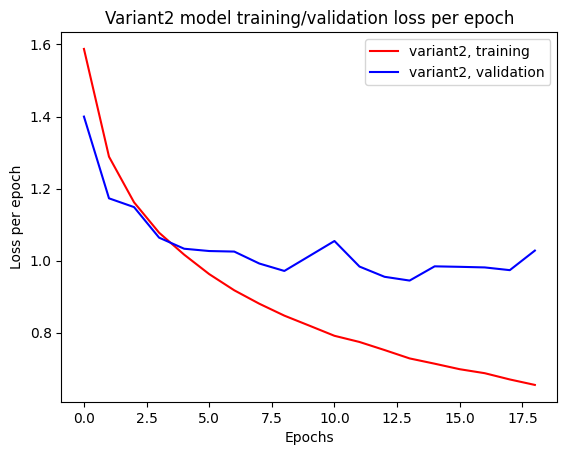

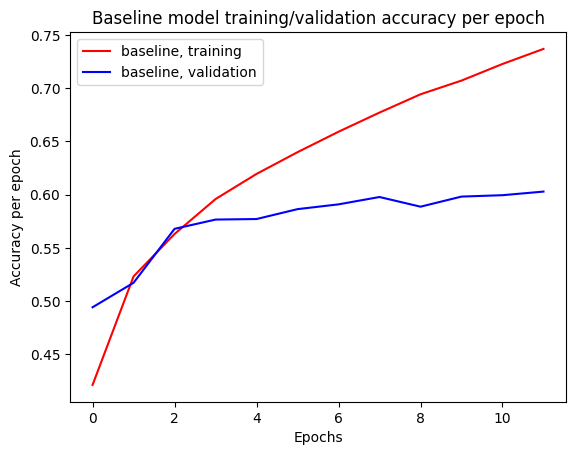

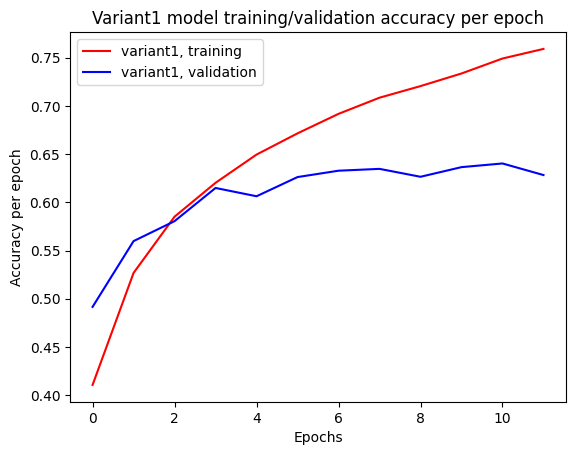

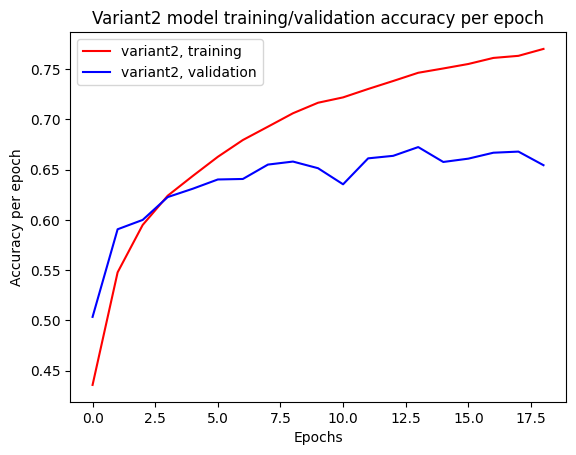

In [ ]:
import matplotlib.pyplot as plt

# Baseline lenet results
with open(f"{output_path}/results/lenet_baseline_results_single_run.json", 'r') as file:
  baseline_results = json.load(file)

# variant1 results
with open(f"{output_path}/results/lenet_batchnorm_results_single_run.json", 'r') as file:
  variant1_results = json.load(file)

# variant2 results
with open(f"{output_path}/results/lenet_bn_dropout_results_single_run.json", 'r') as file:
  variant2_results = json.load(file)

# read accuracy lists
baseline_training_accuracies = baseline_results["0"]["training_accuracy_per_epoch"]
variant1_training_accuracies = variant1_results["0"]["training_accuracy_per_epoch"]
variant2_training_accuracies = variant2_results["0"]["training_accuracy_per_epoch"]

baseline_validation_accuracies = baseline_results["0"]["validation_accuracy_per_epoch"]
variant1_validation_accuracies = variant1_results["0"]["validation_accuracy_per_epoch"]
variant2_validation_accuracies = variant2_results["0"]["validation_accuracy_per_epoch"]

# read loss lists
baseline_training_losses = baseline_results["0"]["training_loss_per_epoch"]
variant1_training_losses = variant1_results["0"]["training_loss_per_epoch"]
variant2_training_losses = variant2_results["0"]["training_loss_per_epoch"]

baseline_validation_losses = baseline_results["0"]["validation_loss_per_epoch"]
variant1_validation_losses = variant1_results["0"]["validation_loss_per_epoch"]
variant2_validation_losses = variant2_results["0"]["validation_loss_per_epoch"]

def plot_epochs(model1, model2, model3, list1, list2, list3, ylabel="efe"):
  num_epochs = len(list1)
  a = [i for i in range(num_epochs)]
  num_epochs = len(list2)
  b = [i for i in range(num_epochs)]
  num_epochs = len(list3)
  c = [i for i in range(num_epochs)]
  plt.xlabel("Epochs")
  plt.ylabel(ylabel)
  plt.plot(a, list1, c="red", label=model1)
  plt.plot(b, list2, c="blue", label=model2)
  plt.plot(c, list3, c="green", label=model3)
  plt.legend()
  plt.show()

# Training accuracies
#plot_epochs("baseline", "variant1", "variant2", baseline_training_accuracies, variant1_training_accuracies, variant2_training_accuracies, ylabel="Training accuracies per epoch")
# Validation accuracies
#plot_epochs("baseline", "variant1", "variant2", baseline_validation_accuracies, variant1_validation_accuracies, variant2_validation_accuracies, ylabel="validation accuracies per epoch")
# Training loss
#plot_epochs("baseline", "variant1", "variant2", baseline_training_losses, variant1_training_losses, variant2_training_losses, ylabel="training losses per epoch")
# Validation loss
#plot_epochs("baseline", "variant1", "variant2", baseline_validation_losses, variant1_validation_losses, variant2_validation_losses, ylabel="validation losses per epoch")



def plot_epochs_(model1, training_list, validation_list, ylabel="efe", title="efe"):
  num_epochs = len(training_list)
  a = [i for i in range(num_epochs)]
  num_epochs = len(validation_list)
  b = [i for i in range(num_epochs)]
  plt.xlabel("Epochs")
  plt.ylabel(ylabel)
  plt.plot(a, training_list, c="red", label=f"{model1}, training")
  plt.plot(b, validation_list, c="blue", label=f"{model1}, validation")
  plt.legend()
  plt.title(title)
  plt.savefig(f"{output_path}/{model1}_{ylabel.split(' ')[0]}.png")
  plt.show()

# Loss
plot_epochs_("baseline", baseline_training_losses, baseline_validation_losses, ylabel="Loss per epoch", title="Baseline model training/validation loss per epoch")
plot_epochs_("variant1", variant1_training_losses, variant1_validation_losses, ylabel="Loss per epoch", title="Variant1 model training/validation loss per epoch")
plot_epochs_("variant2", variant2_training_losses, variant2_validation_losses, ylabel="Loss per epoch", title="Variant2 model training/validation loss per epoch")

# Accuracy
plot_epochs_("baseline", baseline_training_accuracies, baseline_validation_accuracies, ylabel="Accuracy per epoch", title="Baseline model training/validation accuracy per epoch")
plot_epochs_("variant1", variant1_training_accuracies, variant1_validation_accuracies, ylabel="Accuracy per epoch", title="Variant1 model training/validation accuracy per epoch")
plot_epochs_("variant2", variant2_training_accuracies, variant2_validation_accuracies, ylabel="Accuracy per epoch", title="Variant2 model training/validation accuracy per epoch")


# Training the best model with Cifar100


In [ ]:
# Read cifar100 data
learning_rate = 0.001
early_stop_tolerance = 10
model_performance = {}

# Transform with normalization
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

fine_to_coarse_map = {
    0: 4, 1: 1, 2: 14, 3: 8, 4: 0, 5: 6, 6: 7, 7: 7, 8: 18, 9: 3,
    10: 3, 11: 14, 12: 9, 13: 18, 14: 7, 15: 11, 16: 3, 17: 9, 18: 7, 19: 11,
    20: 6, 21: 11, 22: 5, 23: 10, 24: 7, 25: 6, 26: 13, 27: 15, 28: 3, 29: 15,
    30: 0, 31: 11, 32: 1, 33: 10, 34: 12, 35: 14, 36: 16, 37: 9, 38: 11, 39: 5,
    40: 5, 41: 19, 42: 8, 43: 8, 44: 15, 45: 13, 46: 14, 47: 17, 48: 18, 49: 10,
    50: 16, 51: 4, 52: 17, 53: 4, 54: 2, 55: 0, 56: 17, 57: 4, 58: 18, 59: 17,
    60: 10, 61: 3, 62: 2, 63: 12, 64: 12, 65: 16, 66: 12, 67: 1, 68: 9, 69: 19,
    70: 2, 71: 10, 72: 0, 73: 1, 74: 16, 75: 12, 76: 9, 77: 13, 78: 15, 79: 13,
    80: 16, 81: 19, 82: 2, 83: 4, 84: 6, 85: 19, 86: 5, 87: 5, 88: 8, 89: 19,
    90: 18, 91: 1, 92: 2, 93: 15, 94: 6, 95: 0, 96: 17, 97: 8, 98: 14, 99: 13
}

# load data
og_train_dataset = torchvision.datasets.CIFAR100(root="./data", train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR100(root="./data", train=False, download=True, transform=transform)
# Convert fine labels to coarse labels
og_train_dataset.targets = [fine_to_coarse_map[label] for label in og_train_dataset.targets]
test_dataset.targets = [fine_to_coarse_map[label] for label in test_dataset.targets]

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


# Stratification for a nice split of training-validation data so that all classes are represented during trainin
training_labels = [og_train_dataset[i][1] for i in range(len(og_train_dataset))]
train_indices, val_indices = train_test_split(
    range(len(og_train_dataset)),
    test_size=0.2,  # 20% validation data
    stratify=training_labels,  # Preserve class distribution
    random_state=42
)

train_dataset = torch.utils.data.Subset(og_train_dataset, train_indices)
val_dataset = torch.utils.data.Subset(og_train_dataset, val_indices)


# Divide traininf data as training-validation
# We use generator for reproducability
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=g)
valid_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=True, generator=g)


# Cifar 100
cifar_100_num_classes = 20

results = {}

# Create an instance of the best model and replace the last layer so that it has 20 inputs
CIFAR100_model = Lenet_dropout().to(device)
CIFAR100_model.name = "cifar100_model"
CIFAR100_model.fc2 = nn.Linear(CIFAR100_model.fc2.in_features, cifar_100_num_classes)

loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(CIFAR100_model.parameters(), lr=learning_rate)

# Train
CIFAR100_model, training_loss_list, validation_loss_list, accuracy_list, accuracy_list_t = train_model(CIFAR100_model, train_loader, valid_loader, num_epochs=num_epochs,num_classes=cifar_100_num_classes, tolerance=early_stop_tolerance)
# Validate
all_probs, all_labels, correct, tot_images, val_loss, precision, recall, avg_precision = validation(CIFAR100_model, valid_loader, save_model_performance=False,run_count=0, num_classes=cifar_100_num_classes)
acc = 100 * correct / tot_images
print(f"Accuracy: {acc}%")
print(f"Training loss list: {training_loss_list}")
print(f"Validation loss list: {validation_loss_list}")
print(f"Last validation loss: {validation_loss_list[-1]}")

results[0] = {"accuracy": acc, "precision": precision, "recall": recall, "avg_precision": avg_precision, "validation_loss": val_loss, "training_loss": training_loss_list[-1]}
results[0]["training_loss_per_epoch"] = training_loss_list
results[0]["validation_loss_per_epoch"] = validation_loss_list
results[0]["validation_accuracy_per_epoch"] = accuracy_list
results[0]["training_accuracy_per_epoch"] = accuracy_list_t
torch.save(CIFAR100_model.state_dict(), f"{output_path}/model_params/cifar100_params.pth")

with open(f"{output_path}/results/cifar100_results_single_run.json", "w") as outfile:
        json.dump(results, outfile)

# get the summary
summary(CIFAR100_model, (3, 32, 32))

# Fine tuning with cifar10

In [ ]:
# Freeze cifar100_model's parameters
CIFAR10_pretrained = CIFAR100_model
CIFAR10_pretrained.name = "cifar10_pretrained"
"""for param in CIFAR10_pretrained.parameters():
  param.requires_grad = False

# Unfreeze the last 3 fully connected layers
for layer in [CIFAR10_pretrained.fc3]:
    for param in layer.parameters():
        param.requires_grad = True"""

CIFAR10_pretrained.fc2 = nn.Linear(CIFAR10_pretrained.fc2.in_features, 10)
CIFAR10_pretrained.to(device)

results = {}
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(CIFAR10_pretrained.parameters(), lr=learning_rate/2)
early_stop_tolerance = 5

# Read data again
og_train_dataset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Stratification for a nice split of training-validation data so that all classes are represented during trainin
training_labels = [og_train_dataset[i][1] for i in range(len(og_train_dataset))]
train_indices, val_indices = train_test_split(
    range(len(og_train_dataset)),
    test_size=0.2,  # 20% validation data
    stratify=training_labels,  # Preserve class distribution
    random_state=42
)

train_dataset = torch.utils.data.Subset(og_train_dataset, train_indices)
val_dataset = torch.utils.data.Subset(og_train_dataset, val_indices)


# Divide traininf data as training-validation
# We use generator for reproducability
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=g)
valid_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=True, generator=g)

# Train
CIFAR10_pretrained, training_loss_list, validation_loss_list, accuracy_list, accuracy_list_t = train_model(CIFAR10_pretrained, train_loader, valid_loader, num_epochs=num_epochs, tolerance=early_stop_tolerance)
# Validate
all_probs, all_labels, correct, tot_images, val_loss, precision, recall, avg_precision = validation(CIFAR10_pretrained, valid_loader, save_model_performance=False,run_count=0)
acc = 100 * correct / tot_images
print(f"Accuracy: {acc}%")
print(f"Training loss list: {training_loss_list}")
print(f"Validation loss list: {validation_loss_list}")
print(f"Last validation loss: {validation_loss_list[-1]}")

results[0] = {"accuracy": acc, "precision": precision, "recall": recall, "avg_precision": avg_precision, "validation_loss": val_loss, "training_loss": training_loss_list[-1]}
results[0]["training_loss_per_epoch"] = training_loss_list
results[0]["validation_loss_per_epoch"] = validation_loss_list
results[0]["validation_accuracy_per_epoch"] = accuracy_list
results[0]["training_accuracy_per_epoch"] = accuracy_list_t

torch.save(CIFAR10_pretrained.state_dict(), f"{output_path}/model_params/cifar10_pretrained_params.pth")

with open(f"{output_path}/results/cifar10_pretrained_results_single_run.json", "w") as outfile:
        json.dump(results, outfile)

# get the summary
summary(CIFAR10_pretrained, (3, 32, 32))

# Testing best model vs. fine tuned model

In [ ]:
import json
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion_matrix(y_true, y_pred, title, save_path):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(title)
    plt.savefig(f"{save_path}/{title.replace(' ', '_')}.png")
    plt.show()

# Test variant2 (best model) vs. Fine tuned model

results_v2 = {}
# variant 2
all_probs_v2, all_labels_v2, correct_v2, tot_images_v2, test_loss_v2, precision_v2, recall_v2, avg_precision_v2 = validation(model_v2, test_loader, save_model_performance=False, run_count=0)
acc_v2 = 100 * correct_v2 / tot_images_v2
print(f"Accuracy: {acc_v2}%")

results_v2[0] = {"accuracy": acc_v2, "precision": precision_v2, "recall": recall_v2, "avg_precision": avg_precision_v2, "validation_loss": test_loss_v2}

with open(f"{output_path}/results/test_cifar10_variant2_pretrained_results.json", "w") as outfile:
    json.dump(results_v2, outfile)

# Generate confusion matrix for model_v2
all_probs_v2 = torch.cat(all_probs_v2) if isinstance(all_probs_v2, list) else torch.tensor(all_probs_v2)
all_labels_v2 = torch.cat(all_labels_v2) if isinstance(all_labels_v2, list) else torch.tensor(all_labels_v2)
y_pred_v2 = torch.argmax(all_probs_v2, dim=1).tolist()
plot_confusion_matrix(all_labels_v2, y_pred_v2, "Confusion Matrix - Variant 2", output_path)

# Fine tuned model
results_ft = {}
all_probs_ft, all_labels_ft, correct_ft, tot_images_ft, test_loss_ft, precision_ft, recall_ft, avg_precision_ft = validation(CIFAR10_pretrained, test_loader, save_model_performance=False, run_count=0)
acc_ft = 100 * correct_ft / tot_images_ft
print(f"Accuracy: {acc_ft}%")

results_ft[0] = {"accuracy": acc_ft, "precision": precision_ft, "recall": recall_ft, "avg_precision": avg_precision_ft, "validation_loss": test_loss_ft}

with open(f"{output_path}/results/test_cifar10_finetuned_pretrained_results.json", "w") as outfile:
    json.dump(results_ft, outfile)

# Generate confusion matrix for model_ft
all_probs_ft = torch.cat(all_probs_ft) if isinstance(all_probs_ft, list) else torch.tensor(all_probs_ft)
all_labels_ft = torch.cat(all_labels_ft) if isinstance(all_labels_ft, list) else torch.tensor(all_labels_ft)
y_pred_ft = torch.argmax(all_probs_ft, dim=1).tolist()
plot_confusion_matrix(all_labels_ft, y_pred_ft, "Confusion Matrix - Fine Tuned Model", output_path)


## Learning Decay & Data Augmentation

In [ ]:
import os
output_path = "./outputs"
os.makedirs(output_path, exist_ok=True)
os.makedirs(output_path + "/model_params", exist_ok=True)
os.makedirs(output_path + "/results", exist_ok=True)

### With Augmented Datset

In [ ]:
# Lenet batch norm + dropot, single training, validation, parameters, and results saving.
set_seed(42)
results = {}
tot_val_loss = 0
tot_training_loss = 0
results["name"] = "lenet_bn_dropout"
max_avg_precision = 0
min_val_loss = float("inf")
early_stop_tolerance = 5


model_au = Lenet_dropout().to(device)
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_au.parameters(), lr=learning_rate)

# Train
model_au, training_loss_list, validation_loss_list, accuracy_list, accuracy_list_t = train_model(model_au, train_loader, valid_loader, num_epochs=num_epochs)
# Validate
all_probs, all_labels, correct, tot_images, val_loss, precision, recall, avg_precision = validation(model_au, valid_loader, save_model_performance=False, run_count=0)
acc = 100 * correct / tot_images
print(f"Accuracy: {acc}%")
print(f"Training loss list: {training_loss_list}")
print(f"Validation loss list: {validation_loss_list}")
print(f"Last validation loss: {validation_loss_list[-1]}")

results[0] = {"accuracy": acc, "precision": precision, "recall": recall, "avg_precision": avg_precision, "validation_loss": val_loss, "training_loss": training_loss_list[-1]}
results[0]["training_loss_per_epoch"] = training_loss_list
results[0]["validation_loss_per_epoch"] = validation_loss_list
results[0]["validation_accuracy_per_epoch"] = accuracy_list
results[0]["training_accuracy_per_epoch"] = accuracy_list_t
torch.save(model_au.state_dict(), f"{output_path}/model_params/lenet_bn_dropout_au_parameters_single_run.pth")
with open(f"{output_path}/results/lenet_bn_dropout_au_results_single_run.json", "w") as outfile:
  json.dump(results, outfile)

# get the summary
summary(model_au, (3, 32, 32))

### With Learning Decay

In [ ]:
# Training
def train_model(model, train_loader, valid_loader, num_epochs=num_epochs, tolerance=early_stop_tolerance, early_stopping=True, num_classes=num_classes):
  loss_func = nn.CrossEntropyLoss()
  def lr_lambda(epoch): # Define a learning rate scheduler that halves the LR every 5 epochs
      return 0.5 ** (epoch // 5)  # Halve the LR every 5 epochs

  optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate)
  scheduler = lr_scheduler.LambdaLR(optimizer, lr_lambda) #Apply the learning rate scheduler
  training_loss_list = []
  validation_loss_list = []
  accuracy_list = []
  accuracy_list_t = []
  learning_rates = []  # Store LR for plotting
  min_val_loss = float('inf') # for early stopping comparisons
  counter = 0 # Count of non-improved epochs
  for epoch in range(num_epochs):
    training_loss = 0.0
    val_loss = 0.0
    correct_t = 0
    tot_images_t = 0
    for step,(batch, labels) in enumerate(train_loader):
      # send data to device
      batch = batch.to(device)
      labels = labels.to(device)
      # Forward pass
      logits = model(batch)
      # Loss
      loss = loss_func(logits, labels)
      # Backward pass
      loss.backward()
      # Update the parameters
      optimizer.step()
      # zero_grad
      optimizer.zero_grad()
      # Accumulate training loss, no need to calculate gradients
      with torch.no_grad():
        training_loss += loss.item()
        # Find the most probable class indices
        _, predicted_labels = torch.max(logits, 1)
        # increase total img count by batch sample size
        tot_images_t += labels.size(0)
        # increase correct classification through bit-wise and
        correct_t += (predicted_labels == labels).sum().item()

         # Track learning rate



    with torch.no_grad():
      _, _, correct, tot_images, val_loss, precision, recall, avg_precision = validation(model, valid_loader, save_model_performance=False, num_classes=num_classes)
      training_loss /= len(train_loader)
      training_loss_list.append(training_loss)
      validation_loss_list.append(val_loss)
      accuracy_list.append(correct / tot_images)
      accuracy_list_t.append(correct_t / tot_images_t)

      current_lr = optimizer.param_groups[0]['lr']
      learning_rates.append(current_lr)
      print(f"Epoch: {epoch+1}, LR={current_lr}, training loss: {training_loss}, validation loss: {val_loss}, validation accuracy: {correct/tot_images}")
      scheduler.step() # Update the learning rate

      # Make validation comparisons and update min loss and counter
      if val_loss < min_val_loss:
        min_val_loss = val_loss
        counter = 0
      else:
        counter +=1

      # Tolerance comparison, if validation error is not getting better break and finish training
      if early_stopping and counter >= tolerance:
        print(f"Training early stopped in epoch: {epoch+1}")
        break

  return model, training_loss_list, validation_loss_list, accuracy_list, accuracy_list_t, learning_rates

In [ ]:
# Lenet batch norm + dropot, single training, validation, parameters, and results saving.
set_seed(42)
results = {}
tot_val_loss = 0
tot_training_loss = 0
results["name"] = "lenet_bn_dropout"
max_avg_precision = 0
min_val_loss = float("inf")
early_stop_tolerance = 5


model_ld = Lenet_dropout().to(device)
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_ld.parameters(), lr=learning_rate)

# Train
model_ld, training_loss_list, validation_loss_list, accuracy_list, accuracy_list_t, learning_rates = train_model(model_ld, train_loader, valid_loader, num_epochs=num_epochs)
# Validate
all_probs, all_labels, correct, tot_images, val_loss, precision, recall, avg_precision = validation(model_ld, valid_loader, save_model_performance=False, run_count=0)
acc = 100 * correct / tot_images
print(f"Accuracy: {acc}%")
print(f"Training loss list: {training_loss_list}")
print(f"Validation loss list: {validation_loss_list}")
print(f"Last validation loss: {validation_loss_list[-1]}")

results[0] = {"accuracy": acc, "precision": precision, "recall": recall, "avg_precision": avg_precision, "validation_loss": val_loss, "training_loss": training_loss_list[-1]}
results[0]["training_loss_per_epoch"] = training_loss_list
results[0]["validation_loss_per_epoch"] = validation_loss_list
results[0]["validation_accuracy_per_epoch"] = accuracy_list
results[0]["training_accuracy_per_epoch"] = accuracy_list_t
torch.save(model_ld.state_dict(), f"{output_path}/model_params/lenet_bn_dropout_ldecay_parameters_single_run.pth")
with open(f"{output_path}/results/lenet_bn_dropout_ldecay_results_single_run.json", "w") as outfile:
  json.dump(results, outfile)

# get the summary
summary(model_ld, (3, 32, 32))

Epoch: 1, LR=0.001, training loss: 1.5450805778503418, validation loss: 1.3391396058634066, validation accuracy: 0.5169
Epoch: 2, LR=0.001, training loss: 1.3125859325885774, validation loss: 1.2663224499446515, validation accuracy: 0.5506


/opt/anaconda3/envs/CVIS/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Average precision score for one or more classes was `nan`. Ignoring these classes in macro-average
  warnings.warn(*args, **kwargs)


Epoch: 3, LR=0.001, training loss: 1.2149138456821442, validation loss: 1.1282760765605842, validation accuracy: 0.6031
Epoch: 4, LR=0.001, training loss: 1.1486079145908357, validation loss: 1.1152924461105762, validation accuracy: 0.6028
Epoch: 5, LR=0.001, training loss: 1.1001059303283691, validation loss: 1.0865514655463613, validation accuracy: 0.6139
Epoch: 6, LR=0.0005, training loss: 1.0157720247745514, validation loss: 1.0010073508698338, validation accuracy: 0.6447
Epoch: 7, LR=0.0005, training loss: 0.9869700465679169, validation loss: 0.9975423228245573, validation accuracy: 0.6454
Epoch: 8, LR=0.0005, training loss: 0.9792562381267548, validation loss: 0.9865499704409713, validation accuracy: 0.6503
Epoch: 9, LR=0.0005, training loss: 0.9548727330446243, validation loss: 0.9958675806514752, validation accuracy: 0.6454
Epoch: 10, LR=0.0005, training loss: 0.9385340780973435, validation loss: 0.9833266661761287, validation accuracy: 0.6513
Epoch: 11, LR=0.00025, training lo

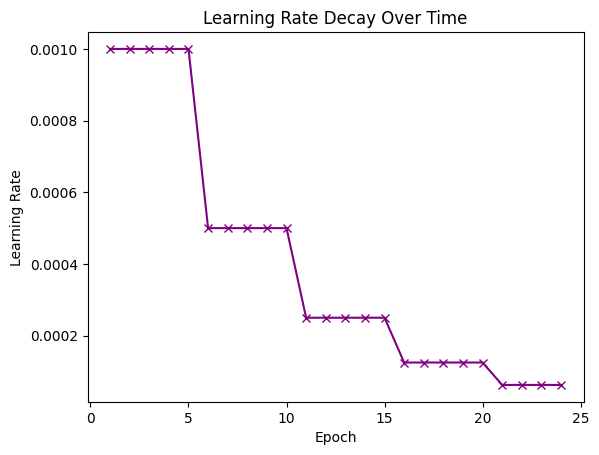

In [ ]:
import matplotlib.pyplot as plt
plt.plot(range(1, len(learning_rates) + 1), learning_rates, marker='x', linestyle='-', color='purple')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Decay Over Time')
plt.show()

# Layer Activation Visualization

In [ ]:
# We first create a new model class to return the activations if forward pass
# Class def for out lenet
class Lenet_activations(nn.Module):
  def __init__(self):
    super(Lenet_activations, self).__init__()
    # initially the images are 3x32x32
    self.relu = nn.ReLU()
    self.conv1 = nn.Conv2d(3, 6, 5) # After convolution1 with 6 kernels we get 6x28x28
    self.pool1 = nn.MaxPool2d(2, 2) # we use max pooling, we get 6x14x14
    self.conv2 = nn.Conv2d(6, 16, 5) # After convolution2 with 16 kernels we get 16x10x10
    self.pool2 = nn.MaxPool2d(2, 2) # after max_pooling 2, we get 16x5x5
    self.fc1 = nn.Linear(16*5*5, 120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84, 10)
    # We dont add the softmax here because torch.CrossEntropyLoss takes logits as inputs
    self.apply(self.init_weights) # apply weight init
    self.name = "Lenet_activations"

  # init weights with kaiming_uniform
  def init_weights(self, module):
      if isinstance(module, nn.Linear) or isinstance(module, nn.Conv2d):
        nn.init.kaiming_uniform_(module.weight, mode='fan_in', nonlinearity='relu')


  # Forward pass function
  def forward(self, x):
    act1 = self.relu(self.conv1(x)) # 1st convolution layer + ReLU activation
    out = self.pool1(act1) # 1st pooling layer
    act2 = self.relu(self.conv2(out)) # 2nd convolution later + ReLU
    out = self.pool2(act2).view(-1, 16*5*5) # 2nd pooling layer + flattening the output to feed into fully connected layers
    out = self.relu(self.fc1(out)) # 1st fully connected layer + ReLU
    out = self.relu(self.fc2(out)) # 2nd fully connected layer + ReLU
    out = self.fc3(out) # 3rd fully connected layer, no ReLU

    return out, act1, act2

  def who(self):
    return self.name

In [ ]:
# Training
def train_model(model, train_loader, valid_loader, num_epochs=num_epochs, tolerance=early_stop_tolerance, early_stopping=True, num_classes=num_classes):
  loss_func = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate)
  training_loss_list = []
  validation_loss_list = []
  accuracy_list = []
  accuracy_list_t = []
  min_val_loss = float('inf') # for early stopping comparisons
  counter = 0 # Count of non-improved epochs
  for epoch in range(num_epochs):
    training_loss = 0.0
    val_loss = 0.0
    correct_t = 0
    tot_images_t = 0
    for step,(batch, labels) in enumerate(train_loader):
      # send data to device
      batch = batch.to(device)
      labels = labels.to(device)
      # Forward pass
      logits, _, _ = model(batch)
      # Loss
      loss = loss_func(logits, labels)
      # Backward pass
      loss.backward()
      # Update the parameters
      optimizer.step()
      # zero_grad
      optimizer.zero_grad()
      # Accumulate training loss, no need to calculate gradients
      with torch.no_grad():
        # Find the most probable class indices
        _, predicted_labels = torch.max(logits, 1)
        # increase total img count by batch sample size
        tot_images_t += labels.size(0)
        # increase correct classification through bit-wise and
        correct_t += (predicted_labels == labels).sum().item()

        training_loss += loss.item()

    with torch.no_grad():
      _, _, correct, tot_images, val_loss, precision, recall, avg_precision = validation(model, valid_loader, save_model_performance=False, num_classes=num_classes)
      training_loss /= len(train_loader)
      training_loss_list.append(training_loss)
      validation_loss_list.append(val_loss)
      accuracy_list.append(correct / tot_images)
      accuracy_list_t.append(correct_t / tot_images_t)

      print(f"Epoch: {epoch+1}, training loss: {training_loss}, validation loss: {val_loss}, validation accuracy: {correct/tot_images}")

      # Make validation comparisons and update min loss and counter
      if val_loss < min_val_loss:
        min_val_loss = val_loss
        counter = 0
      else:
        counter +=1

      # Tolerance comparison, if validation error is not getting better break and finish training
      if early_stopping and counter >= tolerance:
        print(f"Training early stopped in epoch: {epoch+1}")
        break

  return model, training_loss_list, validation_loss_list, accuracy_list, accuracy_list_t


# Validation
def validation(model, dataloader, save_model_performance=False, run_count=0, num_classes=num_classes):
  model_performance = {}
  loss_func = nn.CrossEntropyLoss()
  model.eval()
  with torch.no_grad():
    # a list for all logits
    all_probs = []
    # a list for all labels
    all_labels = []
    # correct classification count
    correct = 0
    # total validation image count
    tot_images = 0
    # If we want class based analysis we can fill the following lists:
    correct_class_counts = [0 for i in range(num_classes)]
    correct_tot_class_counts = [0 for i in range(num_classes)]
    val_loss = 0.0
    # batch by batch
    for step, (valid_batch, valid_labels) in enumerate(dataloader):
      # send data to device
      valid_batch = valid_batch.to(device)
      valid_labels = valid_labels.to(device)
      # Forward pass
      pred_logit, _, _ = model(valid_batch)
      all_probs.append(pred_logit)
      all_labels.append(valid_labels)

      # Find the most probable class indices
      _, predicted_labels = torch.max(pred_logit, 1)
      # increase total img count by batch sample size
      tot_images += valid_labels.size(0)
      # increase correct classification through bit-wise and
      correct += (predicted_labels == valid_labels).sum().item()
      # accumulate val_loss for early stopping
      val_loss += loss_func(pred_logit, valid_labels).item()

      all_probs_t = torch.cat(all_probs, dim=0)
      all_labels_t = torch.cat(all_labels, dim=0)

      # Now that we have the lists, we can iteratively calculate performance metrics
      # Accuracy
      accuracy = metrics.multiclass_accuracy(all_probs_t, all_labels_t, num_classes=num_classes)
      # F1 score
      f1_score = metrics.multiclass_f1_score(all_probs_t, all_labels_t, num_classes=num_classes)
      # Precision
      precision = metrics.multiclass_precision(all_probs_t, all_labels_t, num_classes=num_classes)
      # Recall
      recall = metrics.multiclass_recall(all_probs_t, all_labels_t, num_classes=num_classes)
      # PR Curve
      pr_curve = metrics.multiclass_precision_recall_curve(all_probs_t, all_labels_t, num_classes=num_classes)
      # Average precision
      avg_precision_metric = MulticlassAveragePrecision(num_classes=num_classes)
      avg_precision = avg_precision_metric(all_probs_t, all_labels_t)


      model_performance["model_name"] = model.who()
      model_performance["accuracy"] = accuracy.item()
      model_performance["precision"] = precision.item()
      model_performance["recall"] = recall.item()
      model_performance["f1_score"] = f1_score.item()
      #model_performance["pr_curve"] = pr_curve
      model_performance["avg_precision"] = avg_precision.item()

      # If we want to save model performance
      if save_model_performance:
        #print(model_performance)

        # Save model performance
        with open(f"{output_path}/{model_performance['model_name']}{str(run_count)}_.json", "w") as outfile:
          json.dump(model_performance, outfile)

    model.train()
    return all_probs, all_labels, correct, tot_images, val_loss/len(dataloader), precision.item(), recall.item(), avg_precision.item()


In [ ]:
 # Divide traininf data as training-validation
# load data
og_train_dataset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Stratification for a nice split of training-validation data so that all classes are represented during trainin
training_labels = [og_train_dataset[i][1] for i in range(len(og_train_dataset))]
train_indices, val_indices = train_test_split(
    range(len(og_train_dataset)),
    test_size=0.2,  # 20% validation data
    stratify=training_labels,  # Preserve class distribution
    random_state=42
)

train_dataset = torch.utils.data.Subset(og_train_dataset, train_indices)
val_dataset = torch.utils.data.Subset(og_train_dataset, val_indices)


# Divide traininf data as training-validation
# We use generator for reproducability
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=g)
valid_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=True, generator=g)

num_epochs = 100
tolerance = 2
model = Lenet_activations().to(device)
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Train
model, training_loss_list, validation_loss_list, accuracy_list, accuracy_list_t = train_model(model, train_loader, valid_loader, num_epochs=num_epochs, tolerance=tolerance)
# Validate
all_probs, all_labels, correct, tot_images, val_loss, precision, recall, avg_precision = validation(model, valid_loader, save_model_performance=False,run_count=0)



Files already downloaded and verified
Files already downloaded and verified
Epoch: 1, training loss: 1.5990804428577423, validation loss: 1.4309796917552766, validation accuracy: 0.4887


/usr/local/lib/python3.11/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Average precision score for one or more classes was `nan`. Ignoring these classes in macro-average
  warnings.warn(*args, **kwargs)


Epoch: 2, training loss: 1.3147960885047913, validation loss: 1.2794476033399662, validation accuracy: 0.5487
Epoch: 3, training loss: 1.1923386603832244, validation loss: 1.2829125649251116, validation accuracy: 0.5487
Epoch: 4, training loss: 1.0971577173233031, validation loss: 1.1782923458864132, validation accuracy: 0.5869
Epoch: 5, training loss: 1.0170640856027604, validation loss: 1.142437367774427, validation accuracy: 0.6024
Epoch: 6, training loss: 0.9576409387350082, validation loss: 1.1472134778674798, validation accuracy: 0.5999
Epoch: 7, training loss: 0.9002086594343185, validation loss: 1.1192643571966372, validation accuracy: 0.618
Epoch: 8, training loss: 0.8439101597070694, validation loss: 1.1352460749994833, validation accuracy: 0.6107
Epoch: 9, training loss: 0.7945270267009735, validation loss: 1.1676296835509352, validation accuracy: 0.6118
Training early stopped in epoch: 9


Saved: /content/drive/MyDrive/cv_p3_outputs/Conv1_Filter_0.png


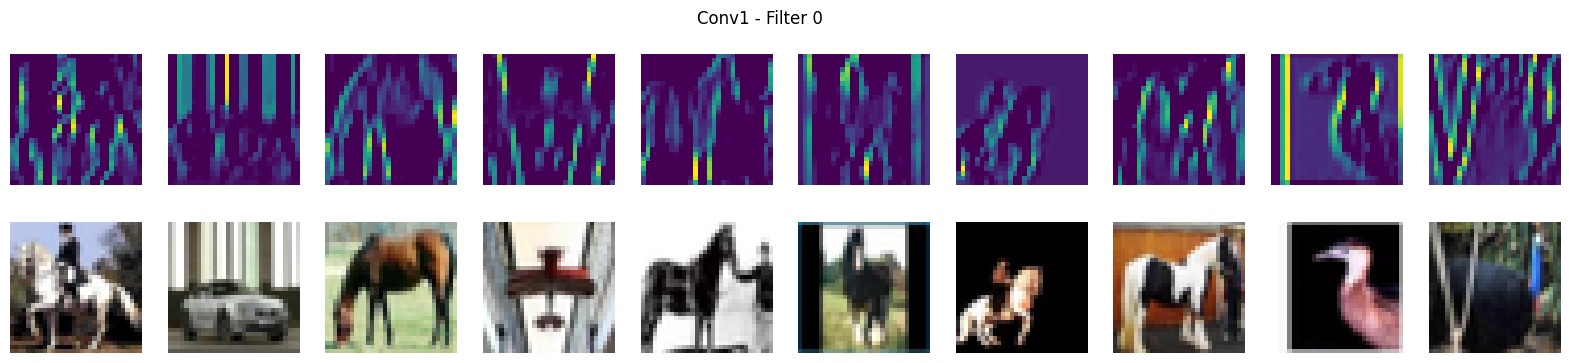

Saved: /content/drive/MyDrive/cv_p3_outputs/Conv1_Filter_1.png


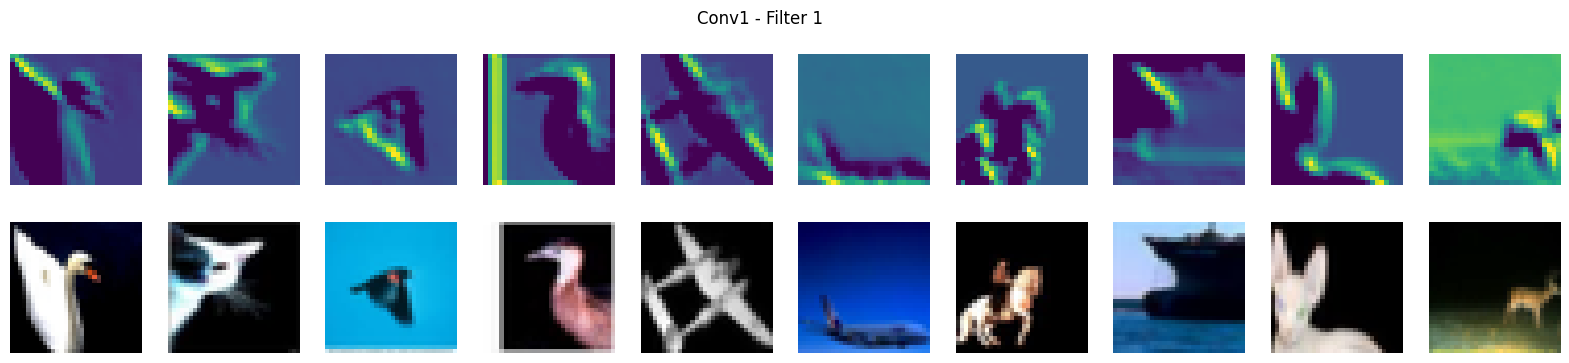

Saved: /content/drive/MyDrive/cv_p3_outputs/Conv1_Filter_2.png


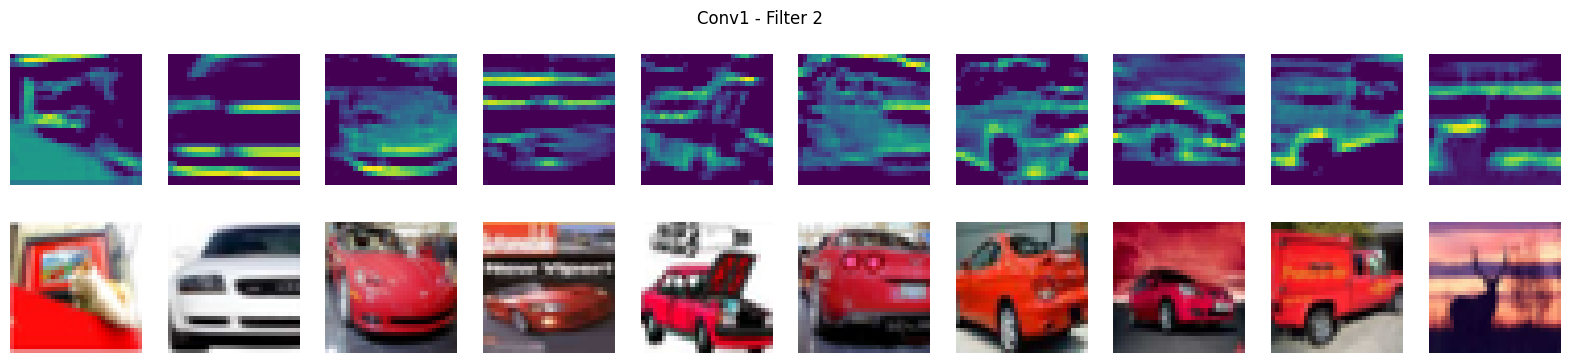

Saved: /content/drive/MyDrive/cv_p3_outputs/Conv1_Filter_3.png


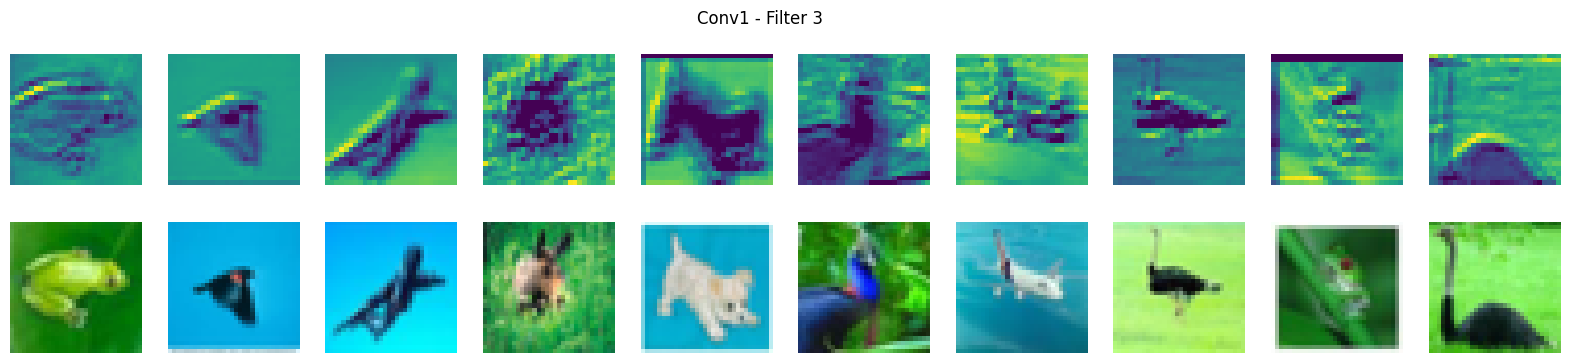

Saved: /content/drive/MyDrive/cv_p3_outputs/Conv1_Filter_4.png


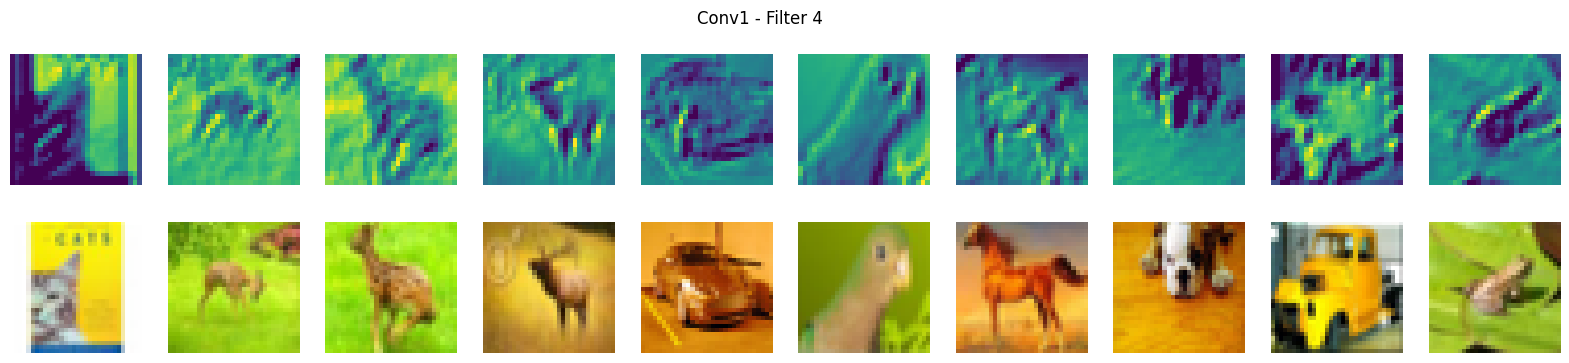

Saved: /content/drive/MyDrive/cv_p3_outputs/Conv1_Filter_5.png


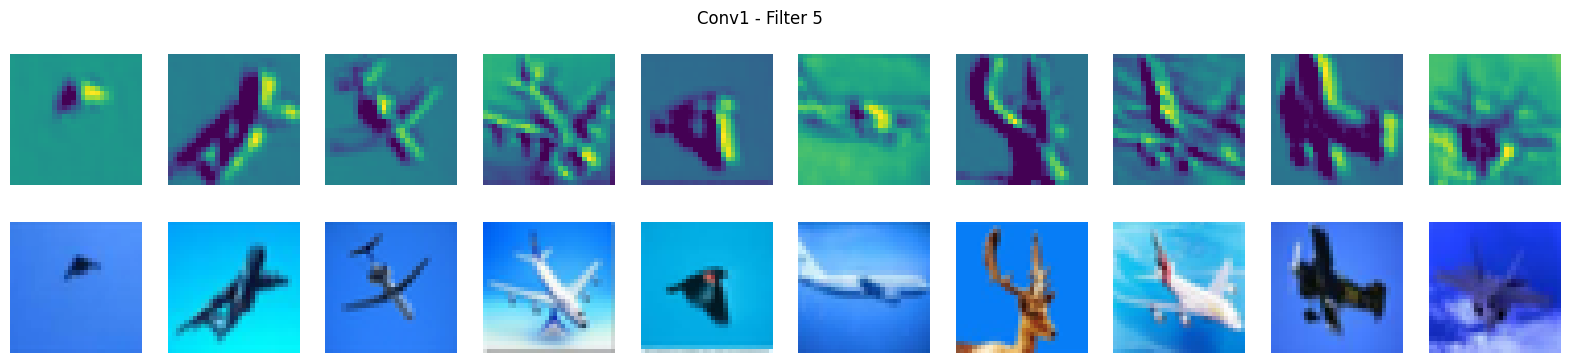

Saved: /content/drive/MyDrive/cv_p3_outputs/Conv2_Filter_0.png


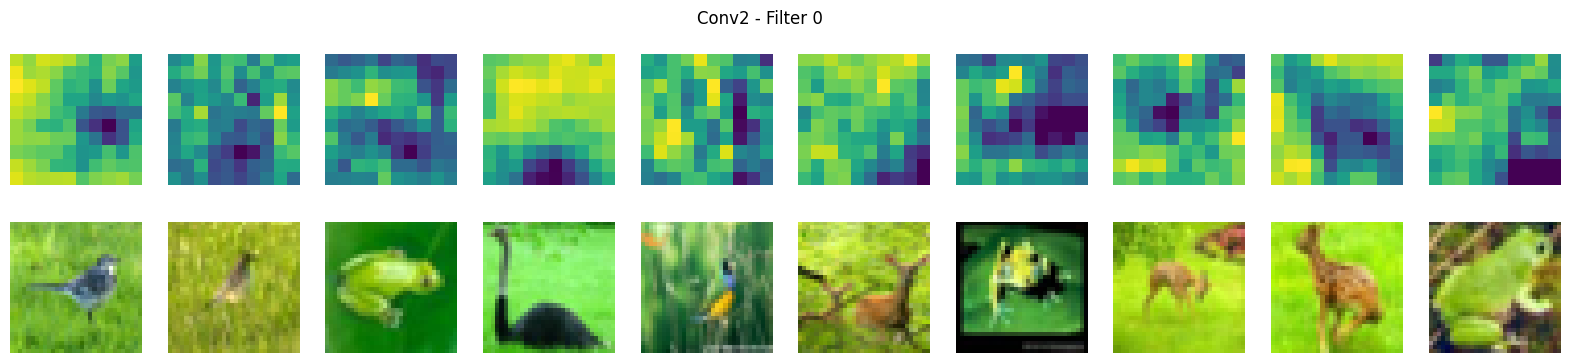

Saved: /content/drive/MyDrive/cv_p3_outputs/Conv2_Filter_1.png


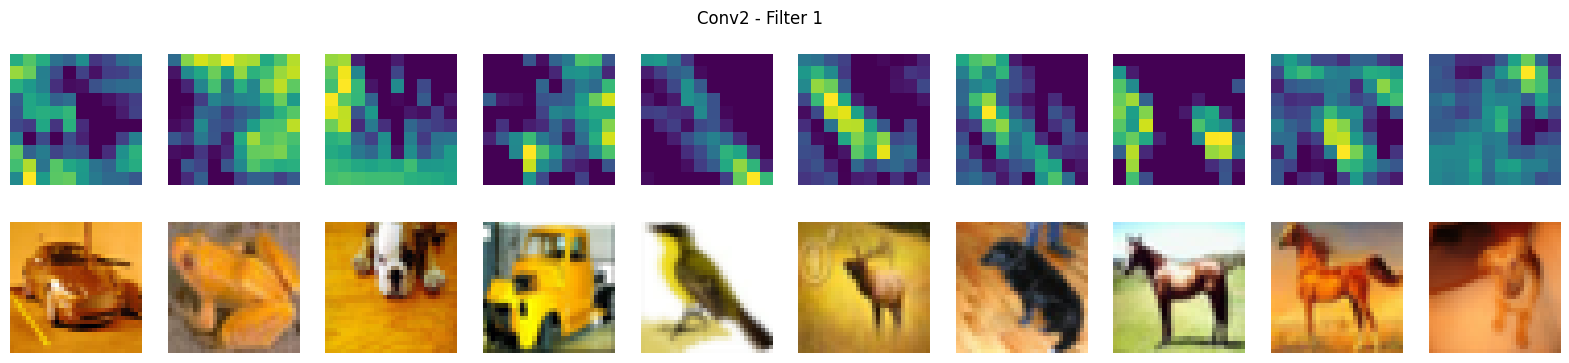

Saved: /content/drive/MyDrive/cv_p3_outputs/Conv2_Filter_2.png


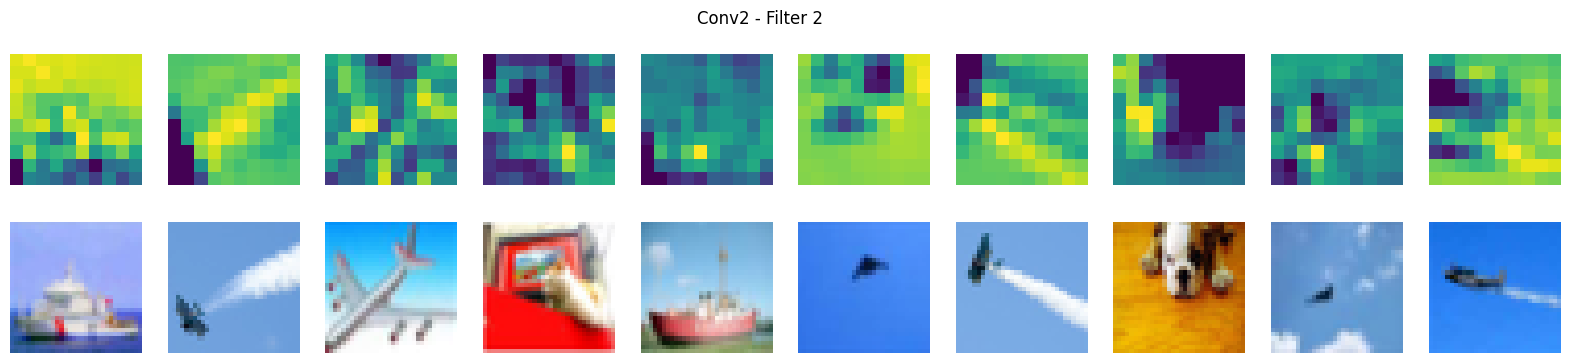

Saved: /content/drive/MyDrive/cv_p3_outputs/Conv2_Filter_3.png


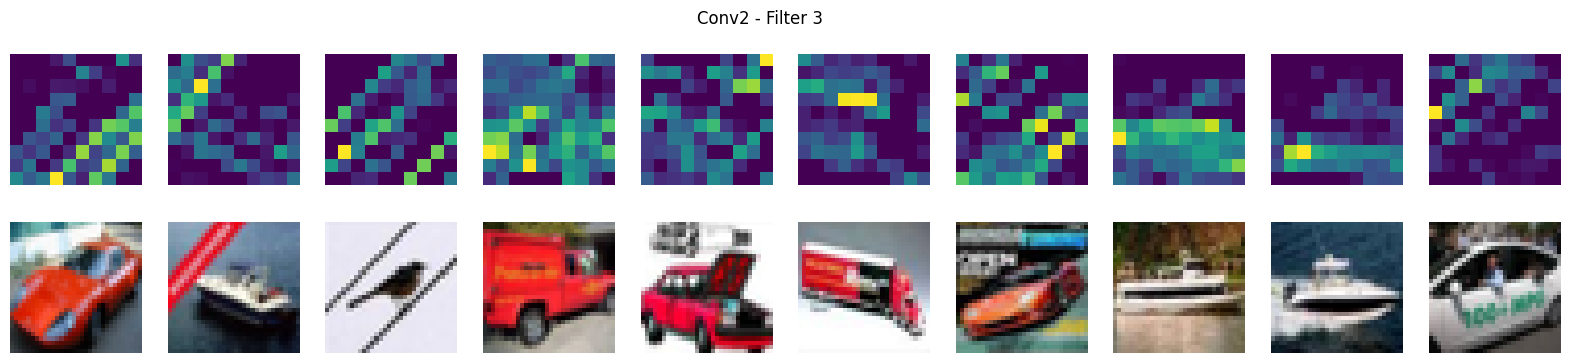

Saved: /content/drive/MyDrive/cv_p3_outputs/Conv2_Filter_4.png


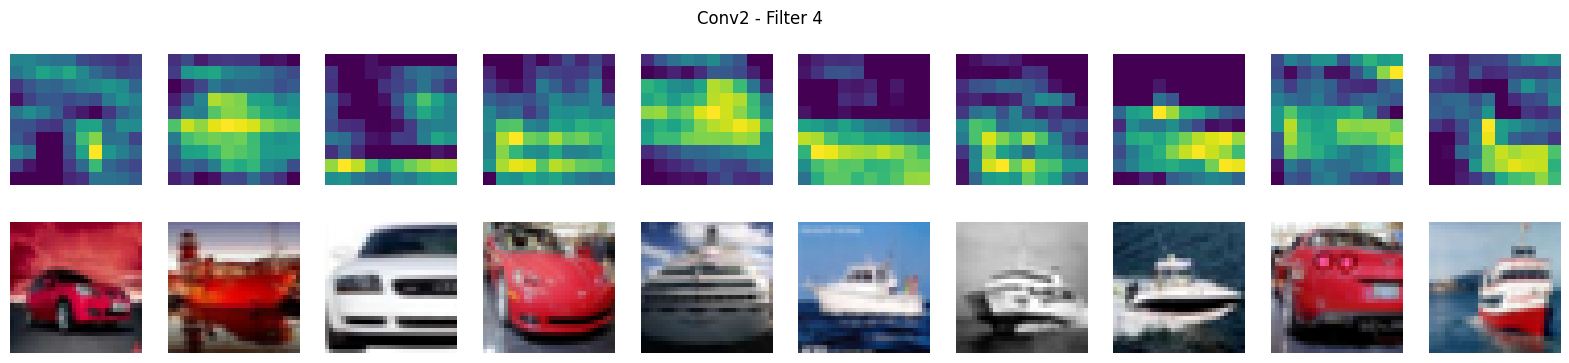

Saved: /content/drive/MyDrive/cv_p3_outputs/Conv2_Filter_5.png


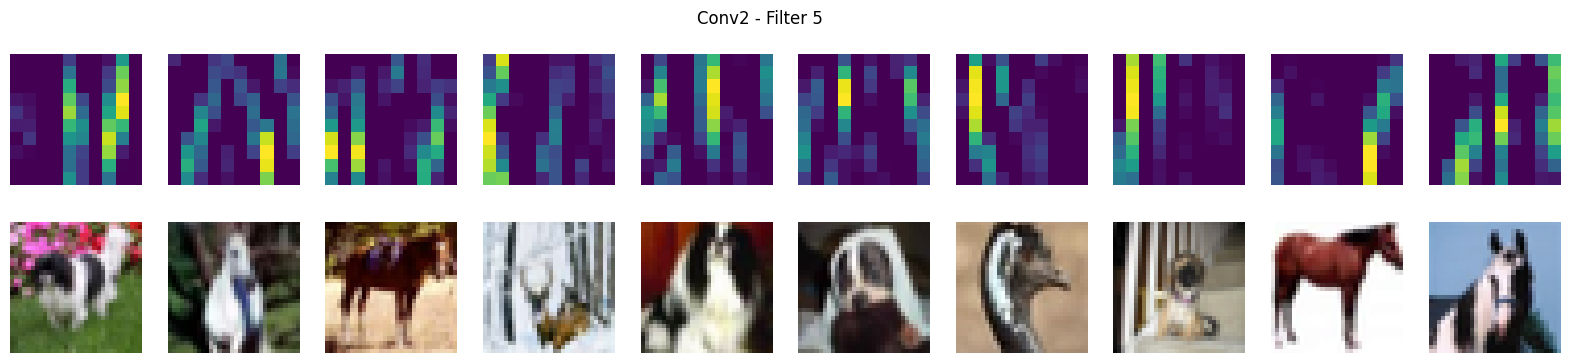

Saved: /content/drive/MyDrive/cv_p3_outputs/Conv2_Filter_6.png


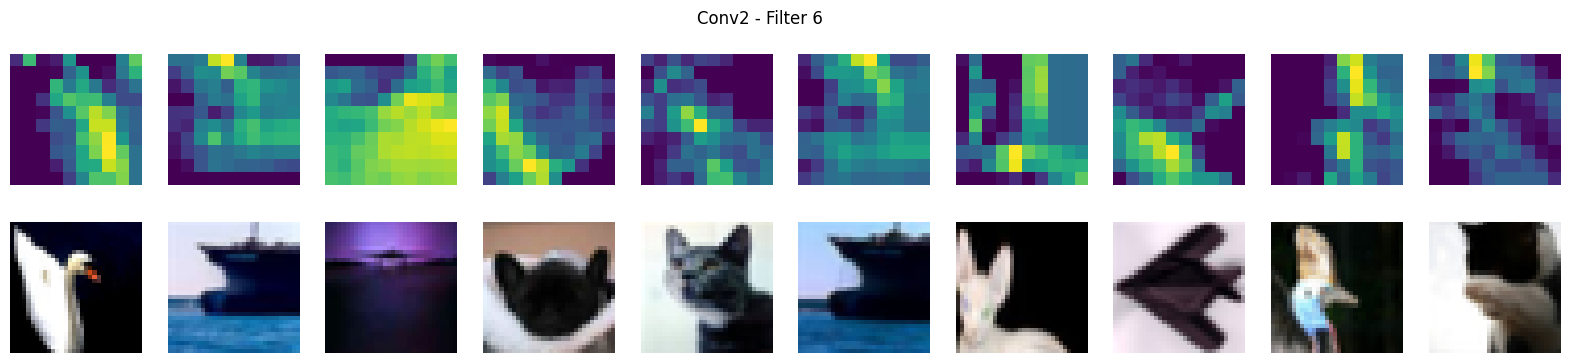

Saved: /content/drive/MyDrive/cv_p3_outputs/Conv2_Filter_7.png


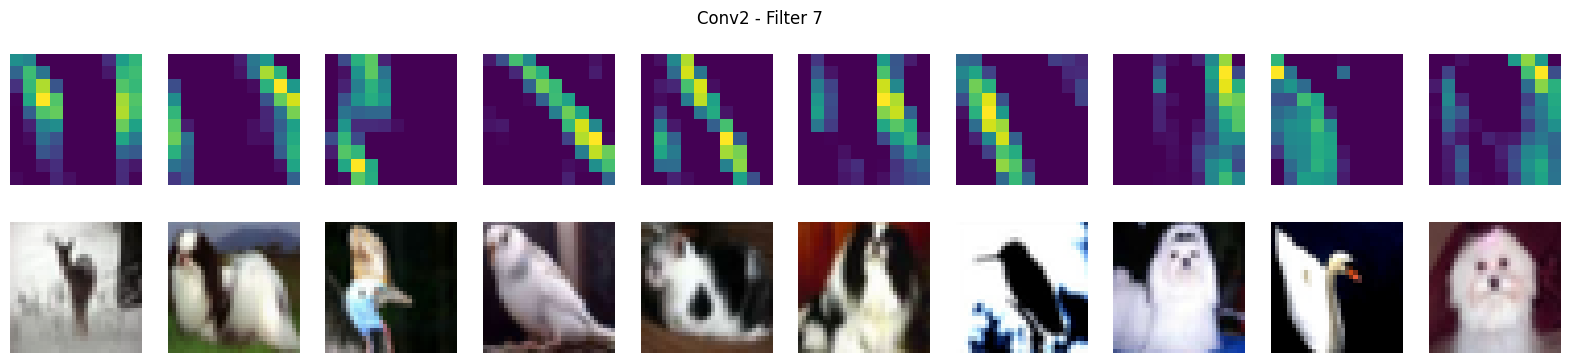

Saved: /content/drive/MyDrive/cv_p3_outputs/Conv2_Filter_8.png


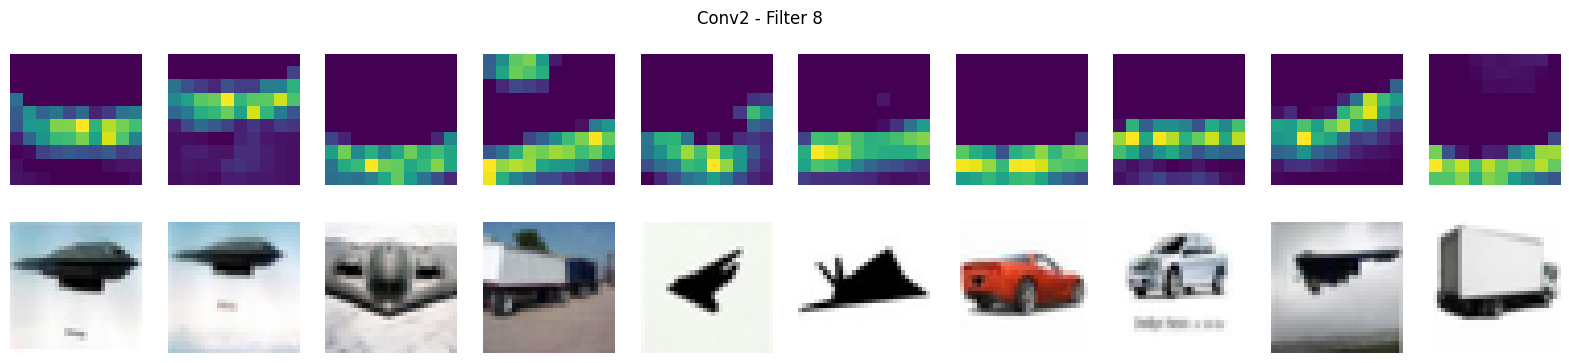

Saved: /content/drive/MyDrive/cv_p3_outputs/Conv2_Filter_9.png


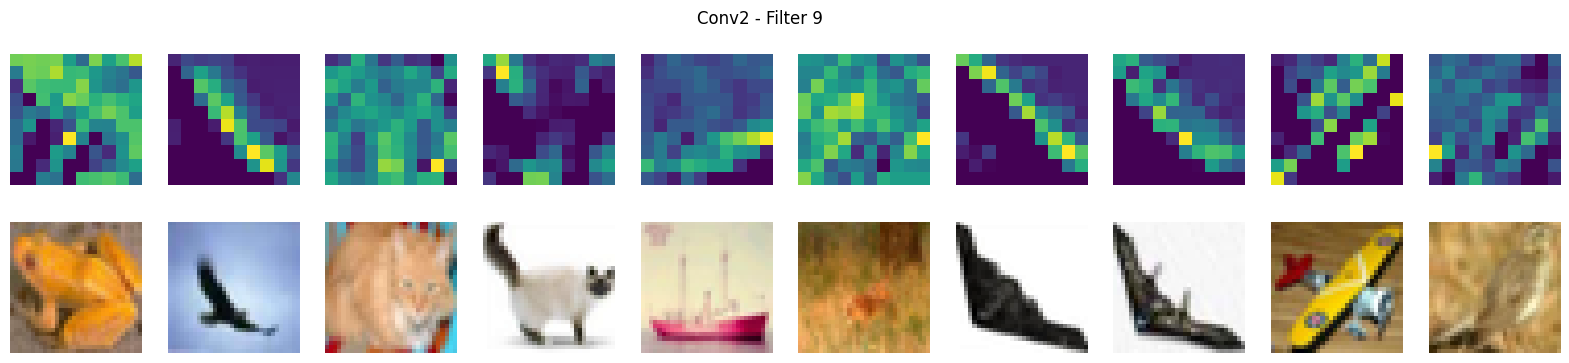

Saved: /content/drive/MyDrive/cv_p3_outputs/Conv2_Filter_10.png


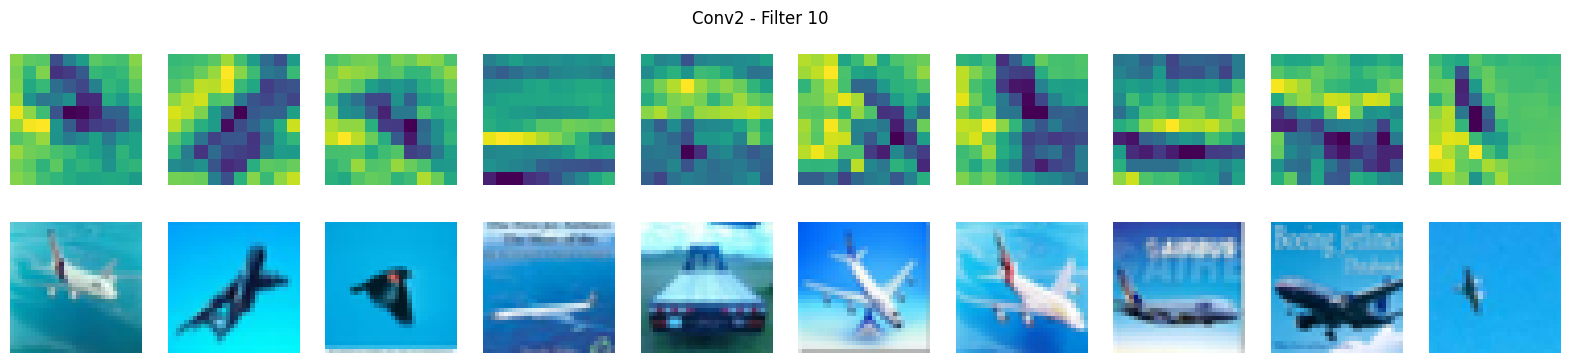

Saved: /content/drive/MyDrive/cv_p3_outputs/Conv2_Filter_11.png


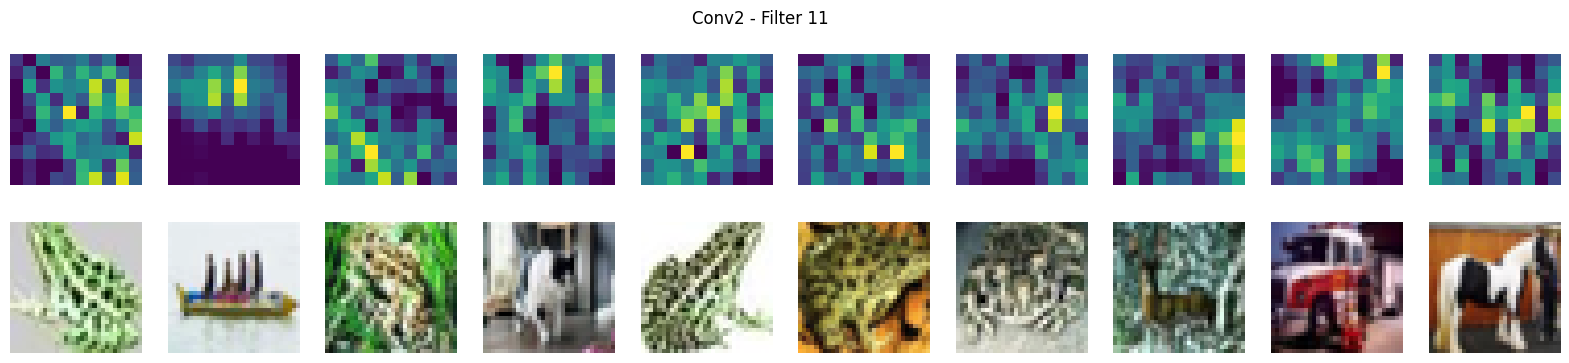

Saved: /content/drive/MyDrive/cv_p3_outputs/Conv2_Filter_12.png


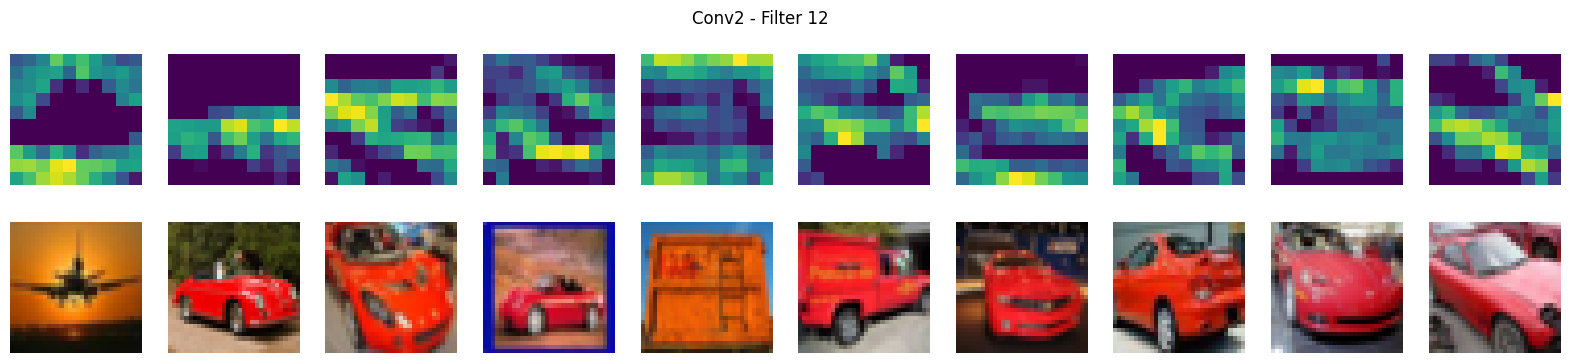

Saved: /content/drive/MyDrive/cv_p3_outputs/Conv2_Filter_13.png


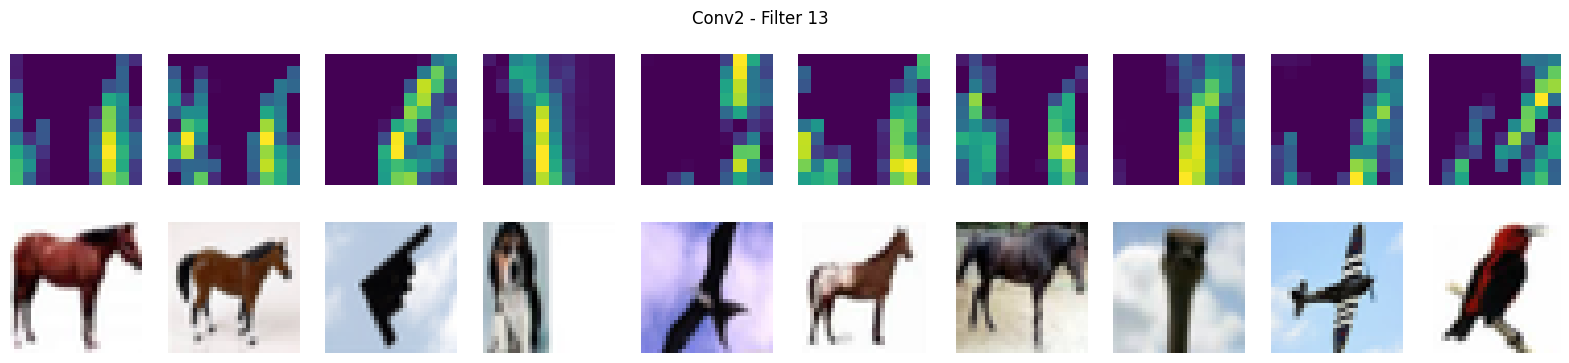

Saved: /content/drive/MyDrive/cv_p3_outputs/Conv2_Filter_14.png


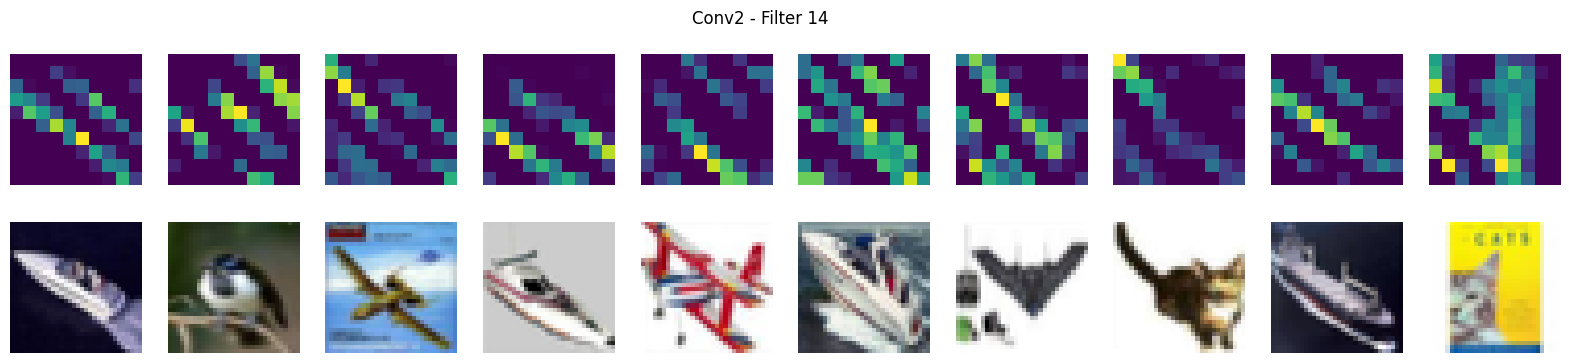

Saved: /content/drive/MyDrive/cv_p3_outputs/Conv2_Filter_15.png


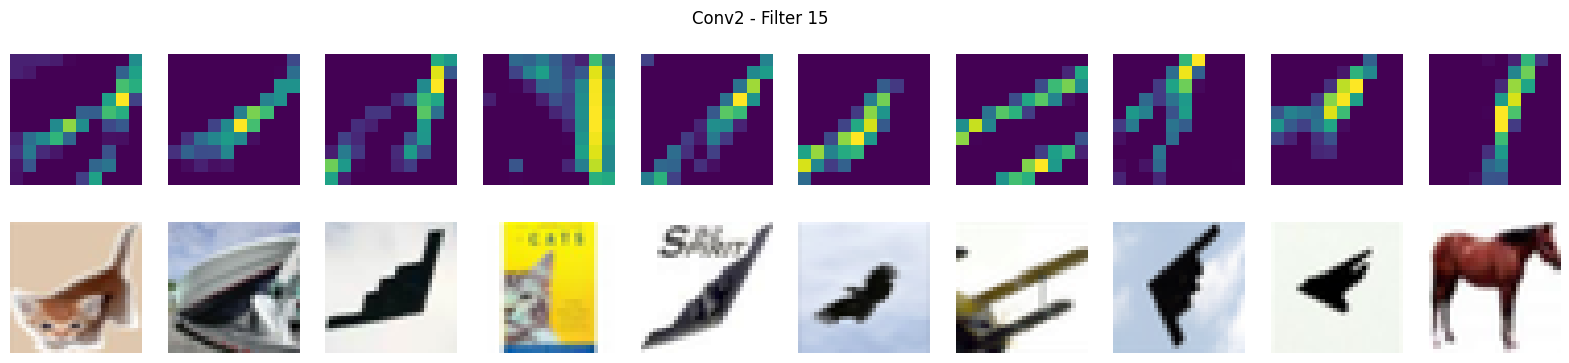

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import torch

# Function to visualize top 10 activations and corresponding images
def visualize_top_activations(filter_activations, filter_images, layer_name, save_path=None):
    num_filters = len(filter_activations)
    for channel in range(num_filters):
        fig, axes = plt.subplots(2, 10, figsize=(20, 4))
        fig.suptitle(f"{layer_name} - Filter {channel}")

        for i in range(len(filter_activations[channel])):
            activation_map = filter_activations[channel][i][1][0, channel].cpu().detach().numpy()
            image = filter_activations[channel][i][0].squeeze().permute(1, 2, 0).numpy()
            image = (image - image.min()) / (image.max() - image.min())

            axes[0, i].imshow(activation_map, cmap="viridis")
            axes[0, i].axis("off")

            axes[1, i].imshow(image)
            axes[1, i].axis("off")

        if save_path:
            plt.savefig(f"{save_path}/{layer_name}_Filter_{channel}.png", bbox_inches="tight")
            print(f"Saved: {save_path}/{layer_name}_Filter_{channel}.png")

        plt.show()
        plt.close()

save_dir = output_path
data_iter = iter(test_loader)

# Get the number of filters dynamically
images, _ = next(data_iter)
image_sample = images[0].unsqueeze(0).to(device)
_, act1_sample, act2_sample = model(image_sample)
num_filters_l1 = act1_sample.shape[1]
num_filters_l2 = act2_sample.shape[1]

# Store the top 10 images for each filter
max_activations = {channel: [] for channel in range(num_filters_l1)}
best_images = {channel: [] for channel in range(num_filters_l1)}

max_activations_l2 = {channel: [] for channel in range(num_filters_l2)}
best_images_l2 = {channel: [] for channel in range(num_filters_l2)}

for i in range(len(data_iter)):
    try:
        images, labels = next(data_iter)
    except StopIteration:
        data_iter = iter(test_loader)  # Reset iterator
        images, labels = next(data_iter)

    for image_ in images:
        image = image_.unsqueeze(0).to(device)

        model.eval()
        with torch.no_grad():
            _, act1, act2 = model(image)

            act1_summed = torch.sum(act1, dim=(2, 3))  # Sum across spatial dimensions
            act2_summed = torch.sum(act2, dim=(2, 3))

            for channel in range(num_filters_l1):
                act_value = act1_summed[0, channel].item()
                if len(max_activations[channel]) < 10:
                    max_activations[channel].append(act_value)
                    best_images[channel].append((image.cpu(), act1.cpu()))
                else:
                    min_idx = np.argmin(max_activations[channel])
                    if act_value > max_activations[channel][min_idx]:
                        max_activations[channel][min_idx] = act_value
                        best_images[channel][min_idx] = (image.cpu(), act1.cpu())

            for channel in range(num_filters_l2):
                act_value = act2_summed[0, channel].item()
                if len(max_activations_l2[channel]) < 10:
                    max_activations_l2[channel].append(act_value)
                    best_images_l2[channel].append((image.cpu(), act2.cpu()))
                else:
                    min_idx = np.argmin(max_activations_l2[channel])
                    if act_value > max_activations_l2[channel][min_idx]:
                        max_activations_l2[channel][min_idx] = act_value
                        best_images_l2[channel][min_idx] = (image.cpu(), act2.cpu())

# Visualize the best 10 images for each filter
visualize_top_activations(best_images, max_activations, "Conv1", save_path=save_dir)
visualize_top_activations(best_images_l2, max_activations_l2, "Conv2", save_path=save_dir)


# t-SNE Visualization

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


model_v2.to(device)
model_v2.eval()

# Extract Features from the last fully connected layer
featuress = []  # Use a list instead of np.array
labels = []

with torch.no_grad():
    for images, lbls in test_loader:
        images = images.to(device)

        # Ensure model returns both predictions and features
        fc_features = model_v2(images, return_features=True)

        # Append features and labels
        featuress.append(fc_features.cpu().numpy())  # Append array to list
        labels.extend(lbls.numpy())  # Use extend to avoid nesting

# Convert lists to numpy arrays
featuress = np.vstack(featuress)  # Stack them into a single array
labels = np.array(labels)  # Convert labels to numpy array

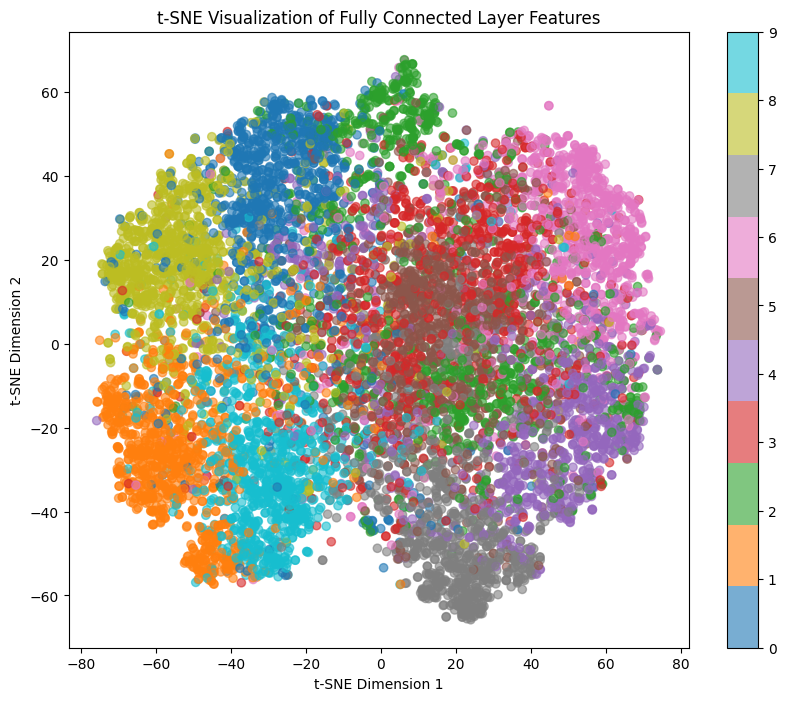

In [ ]:
# Apply t-SNE
# from sklearn.decomposition import PCA
# features_pca = PCA(n_components=50).fit_transform(featuress)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_results = tsne.fit_transform(featuress)

# Plot the t-SNE visualization
plt.figure(figsize=(10, 8))
scatter = plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=labels, cmap='tab10', alpha=0.6)
plt.colorbar(scatter, ticks=range(10))
plt.title("t-SNE Visualization of Fully Connected Layer Features")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()

# Statistical Analysis of the 3 models

In [ ]:
# Lenet baseline
# The code to validate the models ultiple times to see which one is really better
set_seed(42)
results = {}
run_count = 10
tot_val_loss = 0
tot_training_loss = 0
results["name"] = "baseline_lenet"
max_avg_precision = 0
min_val_loss = float("inf")
for i in range(run_count):
   # Divide traininf data as training-validation
  train_data, valid_data = torch.utils.data.random_split(train_dataset, [0.8, 0.2])
  train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
  valid_loader = torch.utils.data.DataLoader(valid_data, batch_size=batch_size, shuffle=True)


  model = Lenet().to(device)
  loss_func = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

  # Train
  model, training_loss_list, validation_loss_list, accuracy_list, accuracy_list_t = train_model(model, train_loader, valid_loader, num_epochs=num_epochs)
  # Validate
  all_probs, all_labels, correct, tot_images, val_loss, precision, recall, avg_precision = validation(model, valid_loader, save_model_performance=False, run_count=i)
  acc = 100 * correct / tot_images
  print(f"Accuracy: {acc}%")
  print(f"Training loss list: {training_loss_list}")
  print(f"Validation loss list: {validation_loss_list}")
  print(f"Last validation loss: {validation_loss_list[-1]}")

  tot_val_loss += val_loss
  tot_training_loss += training_loss_list[-1]

  results[str(i)] = {"accuracy": acc, "precision": precision, "recall": recall, "avg_precision": avg_precision, "validation_loss": val_loss, "training_loss": training_loss_list[-1]}
  results[str(i)]["training_loss_per_epoch"] = training_loss_list
  results[str(i)]["validation_loss_per_epoch"] = validation_loss_list
  results[str(i)]["validation_accuracy_per_epoch"] = accuracy_list
  results[str(i)]["training_accuracy_per_epoch"] = accuracy_list_t
  if avg_precision > max_avg_precision:
    max_avg_precision = avg_precision
    torch.save(model.state_dict(), f"{output_path}/lenet_baseline_best_avg_precision.pth")

results["avg_validation_loss"] = tot_val_loss/run_count
print(results)
with open(f"{output_path}/base_line_lenet_comparison.json", "w") as outfile:
        json.dump(results, outfile)




Epoch: 1, training loss: 1.5707548954010009, validation loss: 1.3729962190500082, validation accuracy: 0.5064
Epoch: 2, training loss: 1.2918345099449158, validation loss: 1.2316386016032186, validation accuracy: 0.5597
Epoch: 3, training loss: 1.1761244010448455, validation loss: 1.1980610903078757, validation accuracy: 0.5709
Epoch: 4, training loss: 1.0953023295402526, validation loss: 1.1913916590495612, validation accuracy: 0.5896
Epoch: 5, training loss: 1.0222256283760072, validation loss: 1.1362339522891913, validation accuracy: 0.6029
Epoch: 6, training loss: 0.964315702009201, validation loss: 1.140122041534692, validation accuracy: 0.6028
Epoch: 7, training loss: 0.9088804814338685, validation loss: 1.141652610545722, validation accuracy: 0.6021
Epoch: 8, training loss: 0.8585145260572433, validation loss: 1.1696176464184405, validation accuracy: 0.6097
Epoch: 9, training loss: 0.811069846534729, validation loss: 1.1509260839928452, validation accuracy: 0.6108
Epoch: 10, tra

In [ ]:
# Lenet Batch normalization
# The code to validate the models ultiple times to see which one is really better
set_seed(42)
results = {}
run_count = 10
tot_val_loss = 0
tot_training_loss = 0
results["name"] = "lenet_bn"
max_avg_precision = 0
min_val_loss = float("inf")
for i in range(run_count):
  # Divide traininf data as training-validation
  train_data, valid_data = torch.utils.data.random_split(train_dataset, [0.8, 0.2])
  train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
  valid_loader = torch.utils.data.DataLoader(valid_data, batch_size=batch_size, shuffle=True)

  model = Lenet_bn().to(device)
  loss_func = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

  # Train
  model, training_loss_list, validation_loss_list, accuracy_list, accuracy_list_t = train_model(model, train_loader, valid_loader, num_epochs=num_epochs)
  # Validate
  all_probs, all_labels, correct, tot_images, val_loss, precision, recall, avg_precision = validation(model, valid_loader, save_model_performance=False,run_count=i)
  acc = 100 * correct / tot_images
  print(f"Accuracy: {acc}%")
  print(f"Training loss list: {training_loss_list}")
  print(f"Validation loss list: {validation_loss_list}")
  print(f"Last validation loss: {validation_loss_list[-1]}")

  tot_val_loss += val_loss
  tot_training_loss += training_loss_list[-1]

  results[str(i)] = {"accuracy": acc, "precision": precision, "recall": recall, "avg_precision": avg_precision, "validation_loss": val_loss, "training_loss": training_loss_list[-1]}
  results[str(i)]["training_loss_per_epoch"] = training_loss_list
  results[str(i)]["validation_loss_per_epoch"] = validation_loss_list
  results[str(i)]["validation_accuracy_per_epoch"] = accuracy_list
  results[str(i)]["training_accuracy_per_epoch"] = accuracy_list_t
  if avg_precision > max_avg_precision:
    max_avg_precision = avg_precision
    torch.save(model.state_dict(), f"{output_path}/lenet_bn_best_avg_precision.pth")

results["avg_validation_loss"] = tot_val_loss/run_count
with open(f"{output_path}/lenet_bn_comparison.json", "w") as outfile:
        json.dump(results, outfile)




In [ ]:
# Lenet batch normalization + dropout
# The code to validate the models ultiple times to see which one is really better
set_seed(42)
results = {}
run_count = 10
tot_val_loss = 0
tot_training_loss = 0
results["name"] = "lenet_dropout"
max_avg_precision = 0
min_val_loss = float("inf")
for i in range(run_count):
  # Divide traininf data as training-validation
  train_data, valid_data = torch.utils.data.random_split(train_dataset, [0.8, 0.2])
  train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)
  valid_loader = torch.utils.data.DataLoader(valid_data, batch_size=batch_size, shuffle=True)

  model = Lenet_dropout().to(device)
  loss_func = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

  # Train
  model, training_loss_list, validation_loss_list, accuracy_list, accuracy_list_t = train_model(model, train_loader, valid_loader, num_epochs=num_epochs)
  # Validate
  all_probs, all_labels, correct, tot_images, val_loss, precision, recall, avg_precision = validation(model, valid_loader, save_model_performance=False, run_count=i)
  acc = 100 * correct / tot_images
  print(f"Accuracy: {acc}%")
  print(f"Training loss list: {training_loss_list}")
  print(f"Validation loss list: {validation_loss_list}")
  print(f"Last validation loss: {validation_loss_list[-1]}")

  tot_val_loss += val_loss
  tot_training_loss += training_loss_list[-1]

  results[str(i)] = {"accuracy": acc, "precision": precision, "recall": recall, "avg_precision": avg_precision, "validation_loss": val_loss, "training_loss": training_loss_list[-1]}
  results[str(i)]["training_loss_per_epoch"] = training_loss_list
  results[str(i)]["validation_loss_per_epoch"] = validation_loss_list
  results[str(i)]["validation_accuracy_per_epoch"] = accuracy_list
  results[str(i)]["training_accuracy_per_epoch"] = accuracy_list_t
  if avg_precision > max_avg_precision:
    max_avg_precision = avg_precision
    torch.save(model.state_dict(), f"{output_path}/lenet_dropout_best_avg_precision.pth")

results["avg_validation_loss"] = tot_val_loss/run_count
with open(f"{output_path}/lenet_dropout_comparison.json", "w") as outfile:
        json.dump(results, outfile)




In [ ]:
# Read the metric jsons
import scipy.stats as stats

with open(f"{output_path}/base_line_lenet_comparison.json") as f:
  baseline_stats = json.load(f)

with open(f"{output_path}/lenet_bn_comparison.json") as f:
  batch_norm_stats = json.load(f) # variant 1

with open(f"{output_path}/lenet_dropout_comparison.json") as f:
  batch_drop_stats = json.load(f) # variant 2

models_stats = [baseline_stats, batch_norm_stats, batch_drop_stats]

models_accs = [[], [], []]
for model_num, model_stats in enumerate(models_stats):
  for ind, val in model_stats.items():
    if ind not in ("name", "avg_validation_loss"):
      models_accs[model_num].append(val["accuracy"])


mean_baseline, std_baseline = np.mean(models_accs[0]), np.std(models_accs[0], ddof=1)
mean_batch_norm, std_batch_norm = np.mean(models_accs[1]), np.std(models_accs[1], ddof=1)
mean_batch_drop, std_batch_drop = np.mean(models_accs[2]), np.std(models_accs[2], ddof=1)

print(f"BASELINE: Mean: {mean_baseline}, STD: {std_baseline}")
print(f"BATCH NORM: Mean: {mean_batch_norm}, STD: {std_batch_norm}")
print(f"BATCH DROP: Mean: {mean_batch_drop}, STD: {std_batch_drop}")

# Comparison 1
# Perform a paired t-test
t_stat, p_value = stats.ttest_ind(models_accs[0], models_accs[1], equal_var=True)

print("---------------")
print("Baseline vs. Batch_norm")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpretation
alpha = 0.05
if p_value < alpha:
    print("The difference in validation loss is statistically significant.")
else:
    print("No significant difference between the models.")

# Comparison 2
# Perform a paired t-test
t_stat, p_value = stats.ttest_ind(models_accs[1], models_accs[2], equal_var=True)

print("---------------")
print("Baseline vs. Batch_norm")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpretation
alpha = 0.05
if p_value < alpha:
    print("The difference in validation loss is statistically significant.")
else:
    print("No significant difference between the models.")


BASELINE: Mean: 60.60699999999999, STD: 1.0509894808650033
BATCH NORM: Mean: 63.355, STD: 0.5470780972077437
BATCH DROP: Mean: 65.982, STD: 0.9275151990368905
---------------
Baseline vs. Batch_norm
T-statistic: -7.3342
P-value: 0.0000
The difference in validation loss is statistically significant.
---------------
Baseline vs. Batch_norm
T-statistic: -7.7145
P-value: 0.0000
The difference in validation loss is statistically significant.
